# Net-Payout-Based Duration

## 0. Setup, Imports, Paths, Session


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes

set_global_plot_style()

# Speicherstruktur fuer Intermediate und Final Output
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_NetPayout"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved figure: {path}")



## 2. Master Panel Construction


In [2]:
# Load annual duration input table (full-history saved as euro500_netpayout)
duration_input = load_parquet("euro500_netpayout").copy()

if "firm_id" not in duration_input.columns:
    raise KeyError("euro500_netpayout must contain firm_id")

duration_input["firm_id"] = duration_input["firm_id"].astype(str).str.strip()

# Ensure Module D field is present already at Step 1 input stage.
if "CashSTInvst" not in duration_input.columns:
    duration_input["CashSTInvst"] = np.nan

# Derive year from the annual observation date (fallback: effective_date)
if "date" in duration_input.columns:
    duration_input["date"] = pd.to_datetime(duration_input["date"], errors="coerce")
    duration_input["year"] = duration_input["date"].dt.year
elif "effective_date" in duration_input.columns:
    duration_input["effective_date"] = pd.to_datetime(duration_input["effective_date"], errors="coerce")
    duration_input["year"] = duration_input["effective_date"].dt.year
elif "year" not in duration_input.columns:
    raise KeyError("euro500_netpayout needs date, effective_date, or year")

# Quarterly EURO500 panel is only the mapping target for final output.
base_euro500 = load_parquet("euro500").copy()
if "firm_id" not in base_euro500.columns:
    raise KeyError("euro500 must contain firm_id")
base_euro500["firm_id"] = base_euro500["firm_id"].astype(str).str.strip()

# Exclude Financials already at master-panel input stage (firm-level filter).
meta_candidates = []
if "trbc_sector" in duration_input.columns:
    meta_candidates.append(
        duration_input[["firm_id", "trbc_sector"]].copy()
    )
if "trbc_sector" in base_euro500.columns:
    meta_candidates.append(
        base_euro500[["firm_id", "trbc_sector"]].copy()
    )

if not meta_candidates:
    raise KeyError("Missing trbc_sector in both euro500_netpayout and euro500; cannot exclude Financials")

sector_map = (
    pd.concat(meta_candidates, ignore_index=True)
    .dropna(subset=["firm_id"])
    .groupby("firm_id", as_index=False)
    .agg({"trbc_sector": "first"})
)
sector_map["trbc_sector"] = sector_map["trbc_sector"].astype(str).str.strip()

financial_ids = set(
    sector_map.loc[
        sector_map["trbc_sector"].str.casefold() == "financials",
        "firm_id",
    ]
)

rows_before = len(duration_input)
firms_before = duration_input["firm_id"].nunique()

duration_input = duration_input.loc[~duration_input["firm_id"].isin(financial_ids)].copy()

rows_after = len(duration_input)
firms_after = duration_input["firm_id"].nunique()

euro500_netpayout = duration_input.copy()

print(
    f"Loaded annual duration input (euro500_netpayout): rows={rows_after:,}, "
    f"firm_id={firms_after:,}"
)
print(
    f"Loaded quarterly mapping base (euro500): rows={len(base_euro500):,}, "
    f"firm_id={base_euro500['firm_id'].nunique():,}"
)
print(
    f"Excluded Financials at input stage: removed rows={rows_before - rows_after:,}, "
    f"removed firms={firms_before - firms_after:,}"
)
print("Step 1 check: CashSTInvst in duration input =", "CashSTInvst" in duration_input.columns)


Loaded annual duration input (euro500_netpayout): rows=12,087, firm_id=946
Loaded quarterly mapping base (euro500): rows=56,500, firm_id=1,248
Excluded Financials at input stage: removed rows=2,097, removed firms=149
Step 1 check: CashSTInvst in duration input = True


### 2.1 Firm-Year Master Panel (ME, BE, Assets, Sales, NI, GP, Debt, Dividends, Buybacks, CashSTInvst)


In [3]:

def build_masterpanel_firmyear(euro500_netpayout):
    """
    Build one row per firm_id-year for valuation/state construction.
    Keeps firm metadata (name) and accounting/value fields.
    """
    df = euro500_netpayout.copy()

    df["firm_id"] = df["firm_id"].astype(str).str.strip()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["firm_id", "year"]).copy()
    df["year"] = df["year"].astype(int)

    for dt_col in ["date", "effective_date"]:
        if dt_col in df.columns:
            df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")

    rename_map = {
        "mcap_eur": "ME",
        "Sales": "sales",
        "NetIncome": "net_income",
        "GrossProfit": "gross_profit",
        "Dividends": "dividends",
        "Buybacks": "buybacks",
    }
    existing_renames = {k: v for k, v in rename_map.items() if k in df.columns}
    if existing_renames:
        df = df.rename(columns=existing_renames)

    cols = [
        "firm_id", "name", "year", "date", "effective_date",
        "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt",
        "dividends", "buybacks", "CashSTInvst",
    ]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].copy()

    value_cols = [
        c for c in [
            "ME", "BE", "assets", "sales", "net_income", "gross_profit", "debt",
            "dividends", "buybacks", "CashSTInvst",
        ] if c in df.columns
    ]
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # one row per firm-year from annual input: prefer year-end observation (latest date in year)
    dedupe_date_cols = [c for c in ["date", "effective_date"] if c in df.columns]
    sort_cols = ["firm_id", "year"] + dedupe_date_cols
    df = df.sort_values(sort_cols)
    df = df.drop_duplicates(subset=["firm_id", "year"], keep="last").reset_index(drop=True)

    # Fehlende Raw-Spalten nicht künstlich mit 0 befüllen.
    # Wenn die Spalte nicht im Input existiert, bleibt sie vollständig NaN.
    if "dividends" not in df.columns:
        df["dividends"] = np.nan
    if "buybacks" not in df.columns:
        df["buybacks"] = np.nan

    # Schritt 1: RAW-Missing-Flags vor jeder Imputation speichern
    df["buybacks_missing"]  = df["buybacks"].isna()
    df["dividends_missing"] = df["dividends"].isna()

    # Schritt 2: Dividenden=0 imputieren wenn Firma aktiv erfasst war
    # Kriterium: ME oder BE vorhanden → Firma war in diesem Jahr in LSEG aktiv.
    # Nur dann bedeutet NaN strukturell "keine Dividenden" (echte Null).
    # Wenn weder ME noch BE vorhanden: datenmäßig dünne Zeile → dividends bleibt NaN.
    _me_num = pd.to_numeric(df["ME"], errors="coerce") if "ME" in df.columns \
              else pd.Series(np.nan, index=df.index)
    _be_num = pd.to_numeric(df["BE"], errors="coerce") if "BE" in df.columns \
              else pd.Series(np.nan, index=df.index)
    _firm_active = _me_num.notna() | _be_num.notna()
    df["dividends"] = np.where(
        _firm_active,
        df["dividends"].fillna(0.0),    # aktiv erfasst → NaN = echte Null
        df["dividends"]                 # datenmäßig dünn → NaN bleibt NaN
    )

    # Schritt 3: Buybacks=0 imputieren wenn Dividenden vorhanden
    # Begründung: LSEG TR.BuyBackRepurchasedValue ist transaktionsbasiert —
    # nur befüllt wenn ein Rückkaufprogramm aktiv war. Kein Programm = NaN,
    # nicht explizit 0. Wenn die Firma Dividenden gemeldet hat, war sie aktiv
    # erfasst → NaN bedeutet "keine Aktivität" = echte Null.
    # Wenn Dividenden AUCH fehlen: gesamte Zeile ist datenmäßig dünn
    # → buybacks bleibt NaN → PO = NaN → Duration NaN (korrekt)
    df["buybacks"] = np.where(
        ~df["dividends_missing"],           # Dividenden vorhanden
        df["buybacks"].fillna(0.0),         # → buybacks NaN ist echte Null
        df["buybacks"]                      # → buybacks NaN bleibt NaN
    )

    # Hauptspezifikation: PO = dividends + buybacks (mit Imputation)
    df["PO"] = df["dividends"] + df["buybacks"]
    print("PO = dividends + buybacks  (buybacks=0 imputiert wenn Dividenden "
          "vorhanden; paper-konform, Gonçalves 2020 Gl. 2)")

    # THESIS: Negative Net-Buyback-Werte bestätigen, dass buybacks netto vorliegen.
    # Netto-Emittenten (Emissionen > Rückkäufe) haben buybacks < 0 — erwartet und korrekt.
    if "buybacks" in df.columns:
        _neg_bb = int((df["buybacks"] < 0).sum())
        _total_bb_obs = max(1, int(df["buybacks"].notna().sum()))
        if _neg_bb > 0:
            print(f"THESIS: {_neg_bb:,} Firmenjahre mit negativen Net Buybacks "
                  f"({_neg_bb / _total_bb_obs:.1%}) — erwartet für Netto-Emittenten. ✓")
        else:
            print(f"THESIS: Keine negativen Buyback-Werte in {_total_bb_obs:,} Beobachtungen. "
                  f"(Alle Firmen sind Netto-Käufer oder BB = 0.)")

    # Robustheitsvariante A: Nur Dividenden (vollständig buyback-unabhängig)
    df["PO_divonly"] = df["dividends"].copy()

    # Robustheitsvariante B: Strict — keine Imputation (nur explizite Buybacks)
    # PO_strict = NaN wenn buybacks_missing, auch wenn Dividenden vorhanden
    df["PO_strict"] = np.where(
        df["buybacks_missing"],
        np.nan,
        df["dividends"] + df["buybacks"]
    )
    df["PO_strict"] = pd.to_numeric(df["PO_strict"], errors="coerce")

    df = df.sort_values(["firm_id", "year"]).reset_index(drop=True)
    lag_vars = [
        c for c in ["ME", "BE", "assets", "sales", "net_income", "gross_profit",
                    "debt", "dividends", "buybacks", "CashSTInvst", "PO", "PO_divonly",
                    "PO_strict"]
        if c in df.columns
    ]
    for c in lag_vars:
        df[f"{c}_lag1"] = df.groupby("firm_id")[c].shift(1)

    df["dBE"]      = df["BE"] - df["BE_lag1"]
    df["avgBE"]    = 0.5 * (df["BE"] + df["BE_lag1"])
    df["avgAssets"] = 0.5 * (df["assets"] + df["assets_lag1"])

    df.loc[df["ME"] <= 0, "ME"]         = pd.NA
    df.loc[df["BE"] <= 0, "BE"]         = pd.NA
    df.loc[df["assets"] <= 0, "assets"] = pd.NA
    df.loc[df["sales"] <= 0, "sales"]   = pd.NA
    df.loc[df["debt"] < 0, "debt"]      = pd.NA

    return df


In [4]:
master = build_masterpanel_firmyear(euro500_netpayout)

master.head()

PO = dividends + buybacks  (buybacks=0 imputiert wenn Dividenden vorhanden; paper-konform, Gonçalves 2020 Gl. 2)
THESIS: 3,483 Firmenjahre mit negativen Net Buybacks (31.7%) — erwartet für Netto-Emittenten. ✓


,firm_id,name,year,date,ME,BE,assets,sales,net_income,gross_profit,...,debt_lag1,dividends_lag1,buybacks_lag1,CashSTInvst_lag1,PO_lag1,PO_divonly_lag1,PO_strict_lag1,dBE,avgBE,avgAssets
0,FIRM0000001,Ahlers AG,1998,1998-11-30,138569059.780975,92670119.59117,201941375.2729,296097820.36271,15384772.70519,145027942.10131,...,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>
1,FIRM0000001,Ahlers AG,1999,1999-11-30,121992375.0,104237075.81947,264407949.56617,305313856.52127,15307056.33925,148917850.73345,...,54100816.53313,1.002132e+07,0.0,20117801.64943,1.002132e+07,1.002132e+07,1.002132e+07,11566956.2283,98453597.70532,233174662.419535
2,FIRM0000001,Ahlers AG,2000,2000-11-30,192793449.999999,108772234.80568,265103817.81648,379503331.06661,14892398.6236,184504276.95659,...,101319133.05349,0.000000e+00,NaN,39481959.06597,NaN,0.000000e+00,NaN,4535158.98621,106504655.312575,264755883.691325
3,FIRM0000001,Ahlers AG,2001,2001-11-30,176409250.0,108458000.0,259187000.0,379731000.0,12857000.0,183741000.0,...,99152278.06098,1.104697e+07,0.0,21139362.82806,1.104697e+07,1.104697e+07,NaN,-314234.80568,108615117.40284,262145408.90824
4,FIRM0000001,Ahlers AG,2002,2002-11-30,162393850.0,107209000.0,251266000.0,350488000.0,12126000.0,173302000.0,...,94053000.0,1.188800e+07,0.0,28166000.0,1.188800e+07,1.188800e+07,NaN,-1249000.0,107833500.0,255226500.0


### Diagnostik: Buyback-Datenverfügbarkeit


BUYBACK-DATENVERFÜGBARKEIT — ÜBERSICHT
Firmenjahre gesamt:                  12,087
Buybacks nicht-NaN:                   7,798  (64.5%)
Dividenden nicht-NaN:                10,025  (82.9%)

Beide vorhanden:                      6,811  (56.3%)
Nur Dividenden:                       3,214  (26.6%)
Nur Buybacks:                           987  (8.2%)
Keines vorhanden:                     1,075  (8.9%)

Firmen mit NIE Buyback-Daten:           162 / 946

Jahre mit Buyback-Coverage < 50%:
      buyback_cov  dividend_cov
year                           
1997        0.382         0.548
1998        0.424         0.565
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/data_availability_dividends_buybacks_po_1999_2024.png


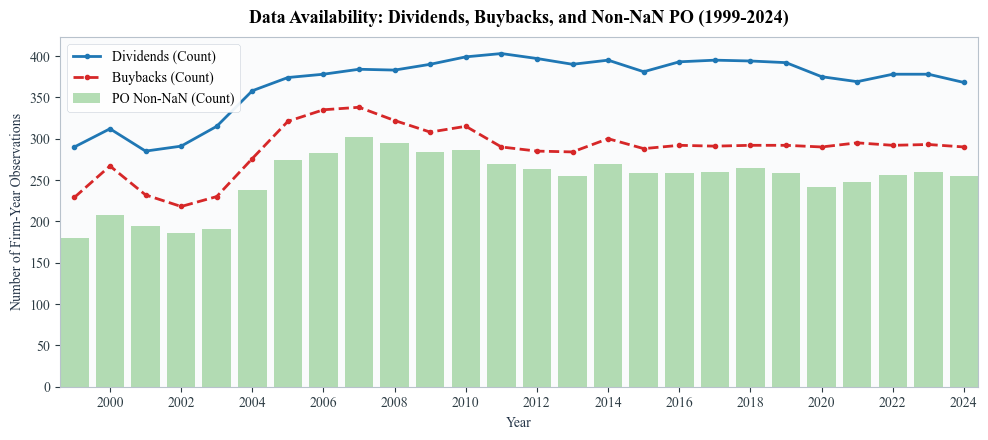




RAW-INPUT-DATENVERFÜGBARKEIT (11 Variablen aus euro500_netpayout)
Inputs geprüft: 11 / 11
Firmenjahre mit 11/11 RAW-Inputs: 6,329 / 12,073 (52.4%)
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/raw_inputs_11_heatmap.png


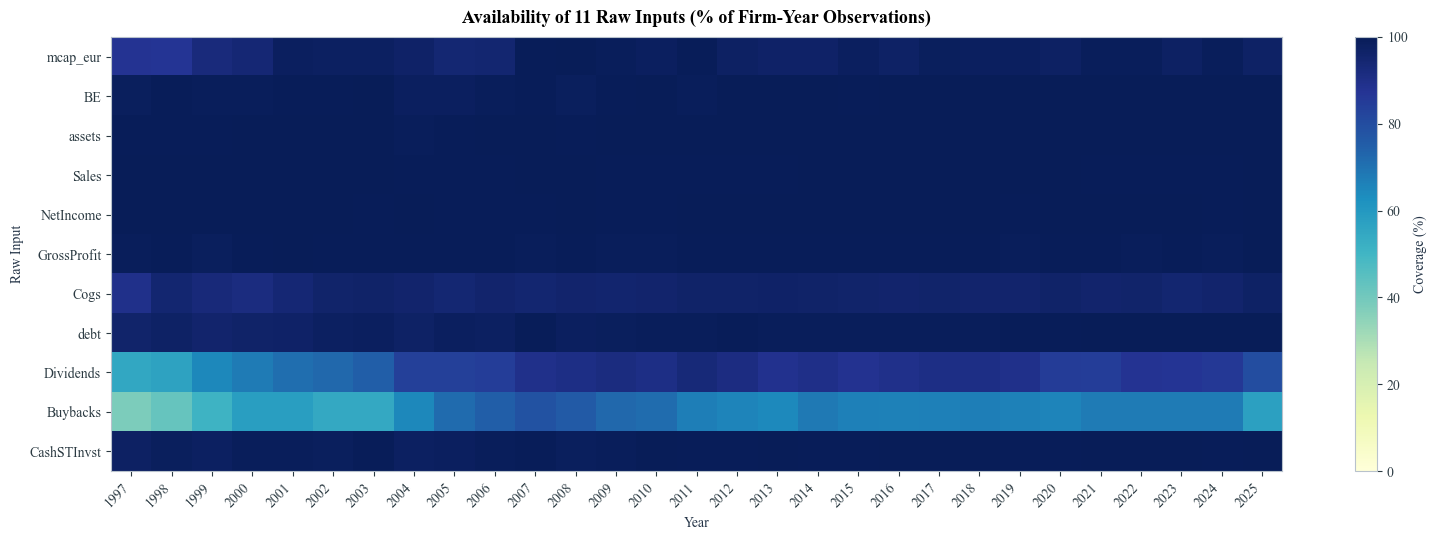

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/raw_inputs_11_ready_counts_and_share.png


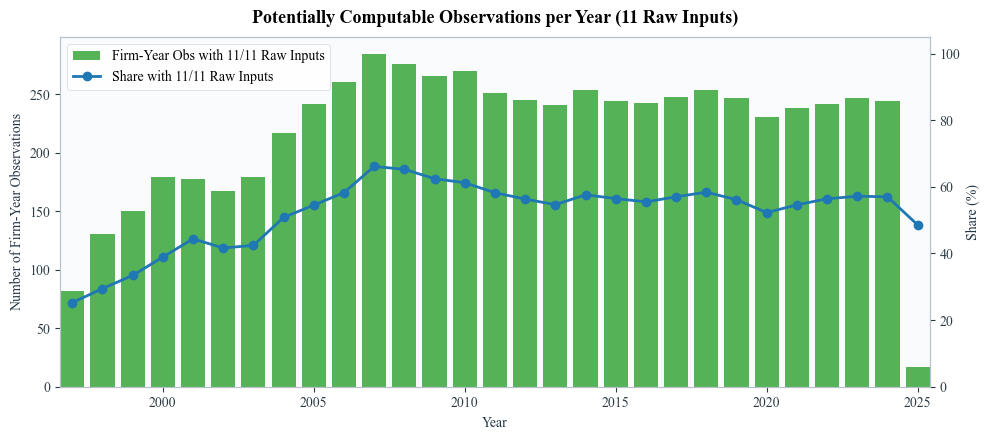


Jahresübersicht (Top 10 niedrigste RAW-Input-Readiness):


,n_firmyears,n_ready_11,share_ready_11_pct
year,,,
1997,325,82,25.2
1998,445,131,29.4
1999,449,150,33.4
2000,460,179,38.9
2002,401,167,41.6
2003,422,179,42.4
2001,401,178,44.4
2025,35,17,48.6
2004,427,217,50.8


In [5]:
# ============================================================
# DIAGNOSTIK: Buyback-Datenverfügbarkeit
# Nutzt euro500_netpayout (RAW, vor build_masterpanel_firmyear)
# ============================================================

_bb_col  = next((c for c in ["Buybacks", "buybacks"] if c in euro500_netpayout.columns), None)
_div_col = next((c for c in ["Dividends", "dividends"] if c in euro500_netpayout.columns), None)

if "year" not in euro500_netpayout.columns:
    _diag = euro500_netpayout.copy()
    if "date" in _diag.columns:
        _diag["year"] = pd.to_datetime(_diag["date"], errors="coerce").dt.year
    elif "effective_date" in _diag.columns:
        _diag["year"] = pd.to_datetime(_diag["effective_date"], errors="coerce").dt.year
else:
    _diag = euro500_netpayout.copy()

_diag["_has_bb"]  = _diag[_bb_col].notna()  if _bb_col  else False
_diag["_has_div"] = _diag[_div_col].notna() if _div_col else False

_n = len(_diag)
print("=" * 60)
print("BUYBACK-DATENVERFÜGBARKEIT — ÜBERSICHT")
print("=" * 60)
print(f"Firmenjahre gesamt:                {_n:>8,}")
print(f"Buybacks nicht-NaN:                {_diag['_has_bb'].sum():>8,}  ({_diag['_has_bb'].mean():.1%})")
print(f"Dividenden nicht-NaN:              {_diag['_has_div'].sum():>8,}  ({_diag['_has_div'].mean():.1%})")
print()
_both   = (_diag["_has_bb"] & _diag["_has_div"]).sum()
_divonly= (~_diag["_has_bb"] & _diag["_has_div"]).sum()
_bbonly = (_diag["_has_bb"] & ~_diag["_has_div"]).sum()
_none   = (~_diag["_has_bb"] & ~_diag["_has_div"]).sum()
print(f"Beide vorhanden:                   {_both:>8,}  ({_both/_n:.1%})")
print(f"Nur Dividenden:                    {_divonly:>8,}  ({_divonly/_n:.1%})")
print(f"Nur Buybacks:                      {_bbonly:>8,}  ({_bbonly/_n:.1%})")
print(f"Keines vorhanden:                  {_none:>8,}  ({_none/_n:.1%})")
print()

# Firmen, die NIE Buyback-Daten haben
_never_bb = _diag.groupby("firm_id")["_has_bb"].any()
print(f"Firmen mit NIE Buyback-Daten:      {(~_never_bb).sum():>8,} / {len(_never_bb):,}")

# Jahre mit Buyback-Coverage < 50%
_by_year = _diag.groupby("year")[["_has_bb", "_has_div"]].mean()
_low_cov = _by_year[_by_year["_has_bb"] < 0.5]
if len(_low_cov):
    print(f"\nJahre mit Buyback-Coverage < 50%:")
    print(_low_cov.rename(columns={"_has_bb": "buyback_cov", "_has_div": "dividend_cov"}).round(3))
else:
    print("Kein Jahr mit Buyback-Coverage < 50%")

# --- Plot: Absolute Datenverfügbarkeit über Zeit (1999-2024) ---
_cov_plot = _diag.groupby("year").agg(
    n_div=("_has_div", "sum"),
    n_bb=("_has_bb", "sum"),
).sort_index()
_cov_plot = _cov_plot.loc[(_cov_plot.index >= 1999) & (_cov_plot.index <= 2024)].copy()

# PO ist nur dann beobachtet, wenn Dividenden UND Buybacks als Raw-Werte vorhanden sind.
_cov_plot["n_po"] = (
    _diag.assign(_has_po=_diag["_has_div"] & _diag["_has_bb"])
         .groupby("year")["_has_po"].sum()
         .reindex(_cov_plot.index)
         .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    _cov_plot.index,
    _cov_plot["n_div"],
    label="Dividends (Count)",
    color="#1f77b4",
    linewidth=2,
    marker="o",
    markersize=3,
)
ax.plot(
    _cov_plot.index,
    _cov_plot["n_bb"],
    label="Buybacks (Count)",
    color="#d62728",
    linewidth=2,
    linestyle="--",
    marker="o",
    markersize=3,
)
ax.bar(
    _cov_plot.index,
    _cov_plot["n_po"],
    label="PO Non-NaN (Count)",
    color="#2ca02c",
    alpha=0.35,
    width=0.8,
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Firm-Year Observations")
ax.set_title("Data Availability: Dividends, Buybacks, and Non-NaN PO (1999-2024)")
ax.set_xticks(list(range(2000, 2025, 2)))
ax.legend(loc="upper left")

plt.tight_layout()
save_figure(fig, "data_availability_dividends_buybacks_po_1999_2024")
plt.show()
print()

print()

# ============================================================
# ZUSATZ-DIAGNOSTIK: Datenverfügbarkeit der 11 RAW-Inputs
# (nur aus euro500_netpayout, ohne PO / ohne Lags)
# ============================================================
_raw_inputs_11 = [
    "mcap_eur", "BE", "assets", "Sales", "NetIncome", "GrossProfit",
    "Cogs", "debt", "Dividends", "Buybacks", "CashSTInvst",
]

_diag_raw = euro500_netpayout.copy()
if "year" not in _diag_raw.columns:
    if "date" in _diag_raw.columns:
        _diag_raw["year"] = pd.to_datetime(_diag_raw["date"], errors="coerce").dt.year
    elif "effective_date" in _diag_raw.columns:
        _diag_raw["year"] = pd.to_datetime(_diag_raw["effective_date"], errors="coerce").dt.year

_diag_raw["year"] = pd.to_numeric(_diag_raw["year"], errors="coerce")
_diag_raw = _diag_raw[_diag_raw["year"].notna()].copy()
_diag_raw["year"] = _diag_raw["year"].astype(int)

# Pro firm_id-year nur eine Beobachtung (wie in der restlichen Pipeline)
_dedupe_cols = ["firm_id", "year"] + [c for c in ["date", "effective_date"] if c in _diag_raw.columns]
_diag_raw = _diag_raw.sort_values(_dedupe_cols).drop_duplicates(["firm_id", "year"], keep="last")

_missing_inputs = [c for c in _raw_inputs_11 if c not in _diag_raw.columns]
if _missing_inputs:
    print("WARNUNG: Fehlende RAW-Inputspalten in euro500_netpayout:", _missing_inputs)

_inputs_available = [c for c in _raw_inputs_11 if c in _diag_raw.columns]

for _c in _inputs_available:
    _diag_raw[f"_has_{_c}"] = _diag_raw[_c].notna()

_has_cols = [f"_has_{_c}" for _c in _inputs_available]
_cov_inputs = _diag_raw.groupby("year")[_has_cols].mean().sort_index()
_cov_inputs.columns = _inputs_available

_diag_raw["_ready_11of11"] = _diag_raw[_inputs_available].notna().all(axis=1)
_ready_by_year = (
    _diag_raw.groupby("year")
    .agg(
        n_firmyears=("firm_id", "size"),
        n_ready_11=("_ready_11of11", "sum"),
    )
    .sort_index()
)
_ready_by_year["share_ready_11"] = _ready_by_year["n_ready_11"] / _ready_by_year["n_firmyears"]

print("\n" + "=" * 60)
print("RAW-INPUT-DATENVERFÜGBARKEIT (11 Variablen aus euro500_netpayout)")
print("=" * 60)
print(f"Inputs geprüft: {len(_inputs_available)} / 11")
print(f"Firmenjahre mit 11/11 RAW-Inputs: "
      f"{int(_diag_raw['_ready_11of11'].sum()):,} / {len(_diag_raw):,} "
      f"({_diag_raw['_ready_11of11'].mean():.1%})")

# --- Plot 1: Heatmap Coverage je RAW-Input und Jahr ---
if len(_inputs_available) and len(_cov_inputs):
    _heat = (_cov_inputs[_inputs_available].T * 100.0)
    fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(_heat.columns)), max(5.5, 0.36 * len(_heat.index))))
    im = ax.imshow(_heat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

    ax.set_xticks(np.arange(len(_heat.columns)))
    ax.set_xticklabels(_heat.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(_heat.index)))
    ax.set_yticklabels(_heat.index)

    ax.set_xlabel("Year")
    ax.set_ylabel("Raw Input")
    ax.set_title("Availability of 11 Raw Inputs (% of Firm-Year Observations)")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Coverage (%)")

    plt.tight_layout()
    save_figure(fig, "raw_inputs_11_heatmap")
    plt.show()

# --- Plot 2: Wie viele Firmenjahre haben 11/11 RAW-Inputs? ---
if len(_ready_by_year):
    fig, ax1 = plt.subplots(figsize=(10, 4.5))

    ax1.bar(
        _ready_by_year.index,
        _ready_by_year["n_ready_11"],
        color="#2ca02c",
        alpha=0.8,
        label="Firm-Year Obs with 11/11 Raw Inputs",
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Number of Firm-Year Observations")

    ax2 = ax1.twinx()
    ax2.plot(
        _ready_by_year.index,
        _ready_by_year["share_ready_11"] * 100,
        color="#1f77b4",
        marker="o",
        linewidth=2,
        label="Share with 11/11 Raw Inputs",
    )
    ax2.set_ylabel("Share (%)")
    ax2.set_ylim(0, 105)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax1.set_title("Potentially Computable Observations per Year (11 Raw Inputs)")
    plt.tight_layout()
    save_figure(fig, "raw_inputs_11_ready_counts_and_share")
    plt.show()

    print("\nJahresübersicht (Top 10 niedrigste RAW-Input-Readiness):")
    display(
        _ready_by_year.sort_values("share_ready_11", ascending=True)
        .head(10)
        .assign(share_ready_11=lambda d: (100 * d["share_ready_11"]).round(1))
        .rename(columns={"share_ready_11": "share_ready_11_pct"})
    )

del _diag, _by_year



## 3. Data Validity Checks

Before constructing state variables, this section checks whether all denominator and transformation conditions are valid (e.g., positivity for log terms and `1+x>0` for `log1p`).

Potential violations are rare, so only a small share of observations is excluded through the `safe_log` / `safe_log1p` guards.


In [6]:
checks = pd.DataFrame({
    
    # valuation
    "ME<=0": (master["ME"] <= 0),
    "BE<=0": (master["BE"] <= 0),
    "sales<=0": (master["sales"] <= 0),
    
    # growth
    "BE_lag1<=0": (master["BE_lag1"] <= 0),
    "assets_lag1<=0": (master["assets_lag1"] <= 0),
    "sales_lag1<=0": (master["sales_lag1"] <= 0),

    # profitability denominators
    "avgBE<=0": (master["avgBE"] <= 0),
    "avgAssets<=0": (master["avgAssets"] <= 0),

    # log1p conditions
    "1+PO/ME<=0": (1 + master["PO"]/master["ME"] <= 0),
    "1+(PO+dBE)/BE_lag1<=0": (1 + (master["PO"] + master["dBE"]) / master["BE_lag1"] <= 0),
    "1+NI/avgBE<=0": (1 + master["net_income"] / master["avgBE"] <= 0),
    "1+GP/avgAssets<=0": (1 + master["gross_profit"] / master["avgAssets"] <= 0),

    # leverage denominator
    "debt+ME<=0": (master["debt"] + master["ME"] <= 0),
})

checks.mean().sort_values(ascending=False)

BE_lag1<=0               0.006777
1+(PO+dBE)/BE_lag1<=0    0.005432
avgBE<=0                 0.005169
1+NI/avgBE<=0            0.003545
sales_lag1<=0            0.001442
1+PO/ME<=0                0.00065
1+GP/avgAssets<=0        0.000091
ME<=0                         0.0
BE<=0                         0.0
sales<=0                      0.0
assets_lag1<=0                0.0
avgAssets<=0                  0.0
debt+ME<=0                    0.0
dtype: Float64

## 4. Construction of Firm-Level State Variables


In this step, we construct the firm-level state variables used in the pooled VAR(1).

The state vector contains exactly 12 variables:
- `bm`, `py`, `sy`, `beg`, `ag`, `sg`, `csprof`, `roe`, `gp`, `lev`, `blev`, `cash`

The clean-surplus profitability definition is:
$$
csprof_{i,t} = \log\left(1 + \frac{PO_{i,t} + \Delta BE_{i,t}}{BE_{i,t-1}}\right).
$$

At this stage, variables are constructed from raw accounting/market inputs; winsorization is applied in Step 4.


In [7]:
def build_state_variables(master):
    df = master.copy()

    def safe_log(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > 0
        out.loc[m] = np.log(x.loc[m])
        return out

    def safe_log1p(x):
        x = pd.to_numeric(x, errors="coerce")
        out = pd.Series(np.nan, index=df.index, dtype=float)
        m = x > -1  # log(1+x) defined iff 1+x > 0
        out.loc[m] = np.log1p(x.loc[m])
        return out

    # Ensure numeric inputs
    num_cols = [
        "BE", "ME", "PO", "sales",
        "BE_lag1", "assets", "assets_lag1", "sales_lag1",
        "dBE", "net_income", "avgBE", "gross_profit", "avgAssets",
        "debt", "CashSTInvst"
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Valuation
    df["bm"] = safe_log(df["BE"] / df["ME"])
    df["py"] = safe_log1p(df["PO"] / df["ME"])
    df["sy"] = safe_log(df["sales"] / df["ME"])

    # Growth
    df["beg"] = safe_log(df["BE"] / df["BE_lag1"])
    df["ag"]  = safe_log(df["assets"] / df["assets_lag1"])
    df["sg"]  = safe_log(df["sales"] / df["sales_lag1"])

    # Profitability
    csprof_raw = (df["PO"] + df["dBE"]) / df["BE_lag1"]
    roe_raw    = df["net_income"] / df["avgBE"]
    gp_raw     = df["gross_profit"] / df["avgAssets"]

    # Optional paper-near floor so log1p stays well-defined
    csprof_raw = csprof_raw.clip(lower=-0.99)
    roe_raw    = roe_raw.clip(lower=-0.99)
    gp_raw     = gp_raw.clip(lower=-0.99)

    df["csprof"] = safe_log1p(csprof_raw)
    df["roe"]    = safe_log1p(roe_raw)
    df["gp"]     = safe_log1p(gp_raw)

    # Robustheitsvarianten: Payout Yield und csprof nur aus Dividenden
    # (buyback-unabhängig; wird nur für Robustheitslauf verwendet, nicht im Haupt-VAR)
    if "PO_divonly" in df.columns:
        df["PO_divonly"] = pd.to_numeric(df["PO_divonly"], errors="coerce")
        df["py_divonly"] = safe_log1p(df["PO_divonly"] / df["ME"])
        csprof_divonly_raw = (df["PO_divonly"] + df["dBE"]) / df["BE_lag1"]
        csprof_divonly_raw = csprof_divonly_raw.clip(lower=-0.99)
        df["csprof_divonly"] = safe_log1p(csprof_divonly_raw)

    # Strict-Variante (für Robustheitscheck): verwendet PO_strict
    if "PO_strict" in df.columns:
        py_strict_raw     = df["PO_strict"] / df["ME"]
        csprof_strict_raw = (df["PO_strict"] + df["dBE"]) / df["BE_lag1"]
        csprof_strict_raw = csprof_strict_raw.clip(lower=-0.99)
        df["py_strict"]     = safe_log1p(py_strict_raw)
        df["csprof_strict"] = safe_log1p(csprof_strict_raw)

    # Capital structure: book leverage and cash holdings
    assets = df["assets"].to_numpy(dtype=float)
    debt   = df["debt"].to_numpy(dtype=float)
    cash   = df["CashSTInvst"].to_numpy(dtype=float)
    me     = df["ME"].to_numpy(dtype=float)

    blev = np.full(len(df), np.nan, dtype=float)
    cash_ratio = np.full(len(df), np.nan, dtype=float)

    mask_assets = assets > 0
    blev[mask_assets] = debt[mask_assets] / assets[mask_assets]
    cash_ratio[mask_assets] = cash[mask_assets] / assets[mask_assets]

    df["blev"] = blev
    df["cash"] = cash_ratio

    # Capital structure: market leverage
    denom = debt + me
    lev = np.full(len(df), np.nan, dtype=float)
    mask_lev = denom > 0
    lev[mask_lev] = debt[mask_lev] / denom[mask_lev]
    df["lev"] = lev

    # Final state variable set
    state_vars = [
        "bm", "py", "sy",
        "beg", "ag", "sg",
        "csprof", "roe", "gp",
        "lev", "blev", "cash"
    ]

    df[state_vars] = df[state_vars].replace([np.inf, -np.inf], np.nan)

    return df


In [8]:
state_panel = build_state_variables(master)

In [9]:
state_vars = [
    "bm","py","sy",
    "beg","ag","sg",
    "csprof","roe","gp",
    "lev","blev","cash"
]

state_panel[state_vars].isna().mean().sort_values(ascending=False)
state_panel[state_vars].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
bm,11571.0,-0.734824,0.799306,-8.299590,-2.912485,-2.090292,-0.684244,0.392147,0.929504,3.639798
py,10757.0,0.015705,0.112135,-3.303208,-0.356657,-0.081985,0.022470,0.091443,0.165637,3.035640
sy,11636.0,-0.174429,1.255092,-12.036174,-3.453586,-2.284557,-0.065024,1.648077,2.357003,5.914028
beg,10935.0,0.113040,0.374250,-5.970282,-0.662272,-0.205781,0.072109,0.579214,1.467445,7.624424
ag,11092.0,0.101838,0.292813,-2.289023,-0.374804,-0.124485,0.057994,0.480936,1.119691,8.411872
sg,11052.0,0.087499,0.348386,-5.752573,-0.705179,-0.205712,0.063087,0.452648,1.025074,7.543115
csprof,10308.0,0.119454,0.468980,-4.605170,-1.017565,-0.179751,0.125982,0.495006,1.138500,7.040358
roe,11002.0,0.103907,0.351099,-4.605170,-0.682904,-0.118966,0.121978,0.342450,0.617622,4.622996
gp,11023.0,0.278821,0.200562,-4.605170,0.008510,0.043969,0.241201,0.644827,0.941259,1.656442
lev,11517.0,0.289222,0.211073,0.000000,0.000377,0.007751,0.257781,0.670066,0.824997,0.979460


THESIS: Verfügbarkeit pro Jahr (1999-2024)


,n_po_non_nan,n_state12_ready,n_both_ready
year,,,
1999,339,278,278
2000,370,315,315
2001,322,298,298
2002,323,295,295
2003,354,325,325
2004,395,364,364
2005,418,373,373
2006,430,376,376
2007,420,392,392


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/po_vs_state12_availability_1999_2024.png


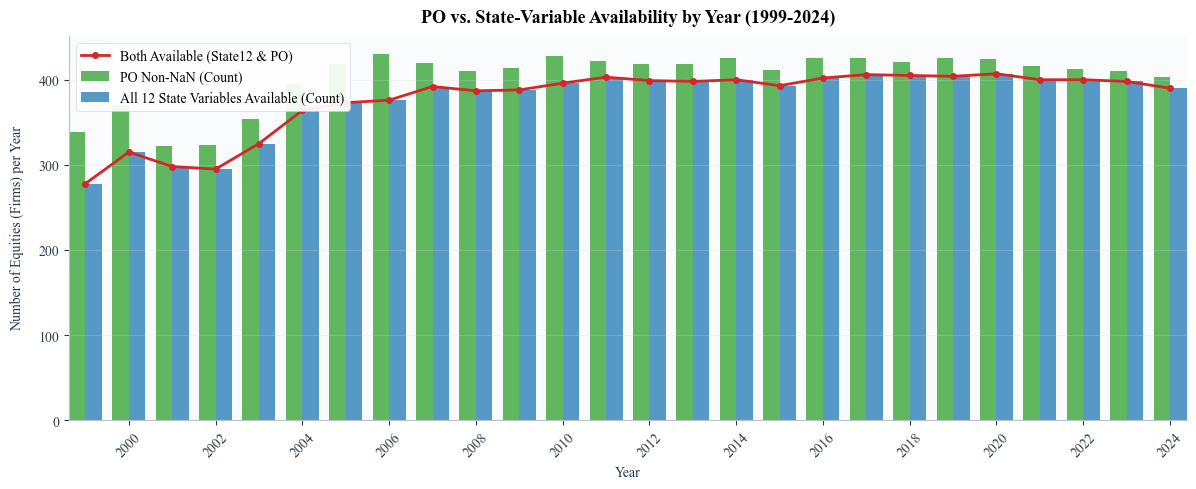

In [10]:
# ============================================================
# DIAGNOSTIK: PO vs. State-Variablen-Verfügbarkeit (1999-2024)
# ============================================================

# Bestehende Schnellübersicht
state_panel.groupby("year")[state_vars].count().tail()

# Eine Equity pro Jahr gilt als "state-ready", wenn alle 12 State-Variablen vorhanden sind.
_state_ready = state_panel[state_vars].notna().all(axis=1)

# PO-Verfügbarkeit aus dem selben firm-year-Panel
_po_ready = state_panel["PO"].notna() if "PO" in state_panel.columns else pd.Series(False, index=state_panel.index)

# Beide Bedingungen gleichzeitig
_both_ready = _state_ready & _po_ready

_tmp_cov = state_panel.assign(
    _state_ready=_state_ready,
    _po_ready=_po_ready,
    _both_ready=_both_ready,
)

_cov_tbl = pd.DataFrame({
    "n_po_non_nan": _tmp_cov[_tmp_cov["_po_ready"]].groupby("year")["firm_id"].nunique(),
    "n_state12_ready": _tmp_cov[_tmp_cov["_state_ready"]].groupby("year")["firm_id"].nunique(),
    "n_both_ready": _tmp_cov[_tmp_cov["_both_ready"]].groupby("year")["firm_id"].nunique(),
}).sort_index().fillna(0).astype(int)

_cov_tbl = _cov_tbl.loc[(_cov_tbl.index >= 1999) & (_cov_tbl.index <= 2024)].copy()

print("THESIS: Verfügbarkeit pro Jahr (1999-2024)")
display(_cov_tbl)

# --- Plot: 2 Balken + 1 Linie ---
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(_cov_tbl.index))
bar_w = 0.38

ax.bar(
    x - bar_w / 2,
    _cov_tbl["n_po_non_nan"].values,
    width=bar_w,
    color="#2ca02c",
    alpha=0.75,
    label="PO Non-NaN (Count)",
)
ax.bar(
    x + bar_w / 2,
    _cov_tbl["n_state12_ready"].values,
    width=bar_w,
    color="#1f77b4",
    alpha=0.75,
    label="All 12 State Variables Available (Count)",
)

ax.plot(
    x,
    _cov_tbl["n_both_ready"].values,
    color="#d62728",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Both Available (State12 & PO)",
)

# Ticks alle 2 Jahre ab 2000
_tick_years = list(range(2000, 2025, 2))
_tick_pos = [i for i, y in enumerate(_cov_tbl.index) if int(y) in _tick_years]
_tick_lbl = [str(int(_cov_tbl.index[i])) for i in _tick_pos]
ax.set_xticks(_tick_pos)
ax.set_xticklabels(_tick_lbl, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Equities (Firms) per Year")
ax.set_title("PO vs. State-Variable Availability by Year (1999-2024)")
ax.legend(loc="upper left")
style_axes(ax)
plt.tight_layout()
save_figure(fig, "po_vs_state12_availability_1999_2024")
plt.show()






## 5. Winsorizing State Variables

State variables are winsorized by year at the 1st and 99th percentiles for robustness before VAR estimation.


In [11]:

# ============================================================
# Winsorize State Variables by YEAR (1% / 99%)
# Paper S. 11, Fn. 7: "I winsorize each non-bounded variable in
# the state vector at 1% and 99% percentiles for each cross-section."
# ============================================================

# lev, blev, cash werden bewusst NICHT winsorisiert (paper-konform):
# Diese Variablen sind durch ihre Definition in [0,1] beschränkt
# (market leverage, book leverage, cash ratio) und brauchen daher
# keine zusätzliche Winsorisierung. Paper Fn. 7 spricht explizit
# von "non-bounded variables".
STATE_VARS_WINSOR = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp"
]

def winsorize_by_year(df, cols, year_col="year", lower=0.01, upper=0.99):
    """
    Jahresweise Winsorisierung (cross-section, kein look-ahead bias).
    Paper S. 11, Fn. 7: "this avoids any look-ahead bias in the winsorization"
    """
    df = df.copy()

    for col in cols:
        lower_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(lower)
        )
        upper_bound = df.groupby(year_col)[col].transform(
            lambda x: x.quantile(upper)
        )
        df[col] = df[col].clip(lower_bound, upper_bound)

    return df


state_panel = winsorize_by_year(
    state_panel,
    STATE_VARS_WINSOR,
    year_col="year"
)

print(f"Winsorisiert: {STATE_VARS_WINSOR}")
print("lev, blev, cash: nicht winsorisiert (bounded in [0,1], paper-konform)")


Winsorisiert: ['bm', 'py', 'sy', 'beg', 'ag', 'sg', 'csprof', 'roe', 'gp']
lev, blev, cash: nicht winsorisiert (bounded in [0,1], paper-konform)


## 6. Estimation of the Firm-Level State VAR

We estimate a pooled VAR(1) on the 12-dimensional state vector using equation-by-equation OLS, without state standardization.

Model form:
$$
x_{t+1} = c + \Phi x_t + u_{t+1}.
$$

The implementation includes a stability check via eigenvalues of `Phi` and forecasting utilities based on the same raw-state transition equation.


In [12]:

# ============================================================
# STEP 5: Firm-Level State VAR(1) — Fama-MacBeth, expanding window
# Gonçalves (2020), S. 13 & Fn. 9; Internet Appendix IA.A
#
# Problem 3 (fix): expanding window — parameters for year t estimated
#                  only on data with year < t (no look-ahead bias)
# Problem 4 (fix): Fama-MacBeth — cross-sectional OLS per year t',
#                  slopes weighted by N_{t'} (Paper S. 13, Fn. 9)
# Problem 5 (fix): intercept calibrated to cross-sectional medians:
#                  const = (I − Φ) @ xbar_target,
#                  xbar_target = time-average of annual cross-sectional medians
# Problem 8 (fix): min_T = 2 (paper S. 9: "minimum of two previous years")
# ============================================================

import statsmodels.api as sm   # kept for any external use; core estimation uses numpy

# ----------------------------
# 5.1 Full state vector (12-dimensional)
# ----------------------------
var_states = [
    "bm", "py", "sy",
    "beg", "ag", "sg",
    "csprof", "roe", "gp",
    "lev", "blev", "cash",
]

TIME_COL = "year"
k = len(var_states)
lead_cols = [f"{v}_lead" for v in var_states]

# ----------------------------
# 5.2 Build VAR sample
#     Each row: (firm, t) with state at t and state at t+1
# ----------------------------
df_var = state_panel.sort_values(["firm_id", TIME_COL]).copy()

for v in var_states:
    df_var[f"{v}_lead"] = df_var.groupby("firm_id")[v].shift(-1)

req_cols = var_states + lead_cols
df_var = df_var.dropna(subset=req_cols).copy()

# Problem 8: minimum 2 consecutive observations per firm (paper S. 9)
min_T = 2
firm_counts = df_var.groupby("firm_id").size()
valid_firms = firm_counts[firm_counts >= min_T].index
df_var = df_var[df_var["firm_id"].isin(valid_firms)].copy()

print("STEP 5 VAR sample:")
print(f"  firms : {df_var['firm_id'].nunique()}")
print(f"  obs   : {len(df_var)}")
print(f"  years : {df_var[TIME_COL].min()} – {df_var[TIME_COL].max()}")

# ----------------------------
# 5.3 Helper functions for Fama-MacBeth VAR estimation
# ----------------------------

def _fama_macbeth_phi(train_df, var_states, time_col, min_cs_obs=None):
    """
    Fama-MacBeth slope matrix.

    For each year t' in train_df, run cross-sectional OLS:
        X_{j,t'+1} = c_{t'} + Φ_{t'} X_{j,t'} + u_{j,t'+1}

    Returns Φ as the N-weighted average of Φ_{t'} across years,
    and the list of per-year sample sizes.
    """
    k = len(var_states)
    lc = [f"{v}_lead" for v in var_states]
    if min_cs_obs is None:
        min_cs_obs = k + 1          # bare minimum for OLS identification

    Phi_list, N_list = [], []

    for _, grp in train_df.groupby(time_col):
        if len(grp) < min_cs_obs:
            continue
        X_t  = grp[var_states].to_numpy(dtype=float)   # (N, k)
        X_t1 = grp[lc].to_numpy(dtype=float)           # (N, k)

        # OLS with intercept:  [1 | X_t] @ β = X_t1
        # β shape: (k+1, k); β[0,:] = intercepts, β[1:,:] = Φ^T
        X_d = np.column_stack([np.ones(len(grp)), X_t])
        try:
            beta, _, _, _ = np.linalg.lstsq(X_d, X_t1, rcond=None)
        except np.linalg.LinAlgError:
            continue

        Phi_list.append(beta[1:, :].T)   # (k, k)
        N_list.append(len(grp))

    if not Phi_list:
        return None, []

    total_N = sum(N_list)
    Phi = sum(n * P for n, P in zip(N_list, Phi_list)) / total_N
    return Phi, N_list


def _calibrate_intercept(Phi, train_df, var_states, time_col):
    """
    Calibrate intercept so that the model's implied steady state equals
    the time-average of annual cross-sectional medians (Paper S. 13):

        const = (I − Φ) @ xbar_target
        xbar_target = mean over years of median(X_{:,t'})
    """
    k = len(var_states)
    annual_medians = (
        train_df.groupby(time_col)[var_states]
        .median()
        .to_numpy(dtype=float)
    )                                   # (T_train, k)
    xbar_target = annual_medians.mean(axis=0)   # (k,)
    const = (np.eye(k) - Phi) @ xbar_target
    return const, xbar_target


def _compute_sigma(train_df, var_states, Phi, const):
    """
    Covariance matrix Σ from firm-demeaned VAR(1) residuals (Paper S. 13):

        u_{j,t} = X_{j,t+1} − const − Φ X_{j,t}
        Σ = Cov(u_tilde),  u_tilde = firm-demeaned u
    """
    k = len(var_states)
    lc = [f"{v}_lead" for v in var_states]

    X_t   = train_df[var_states].to_numpy(dtype=float)     # (N, k)
    X_t1  = train_df[lc].to_numpy(dtype=float)             # (N, k)
    firms = train_df["firm_id"].to_numpy()

    # Raw residuals
    resid = X_t1 - const[np.newaxis, :] - (Phi @ X_t.T).T  # (N, k)

    # Firm-demean using numpy groupby via unique
    unique_f, f_idx = np.unique(firms, return_inverse=True)
    firm_sums  = np.zeros((len(unique_f), k))
    firm_cnts  = np.bincount(f_idx)
    np.add.at(firm_sums, f_idx, resid)
    firm_means = firm_sums / firm_cnts[:, np.newaxis]       # (n_firms, k)

    resid_dm = resid - firm_means[f_idx]                    # (N, k)

    Sigma = (resid_dm.T @ resid_dm) / len(resid_dm)
    return Sigma


# ----------------------------
# 5.4 Expanding-window Fama-MacBeth estimation
# ----------------------------

def estimate_var_expanding(df_var, var_states, time_col="year", min_cs_obs=None):
    """
    Fama-MacBeth VAR(1) with expanding window.

    For each year t, parameters are estimated using all observations
    with year < t (no look-ahead bias).

    Returns
    -------
    var_params_by_year : dict {year: (Phi, const, Sigma)}
        Phi  : (k, k)  transition matrix
        const: (k,)    intercept calibrated to cross-sectional medians
        Sigma: (k, k)  residual covariance from firm-demeaned residuals
    """
    all_years = sorted(df_var[time_col].unique())
    params = {}

    for t in all_years:
        train = df_var[df_var[time_col] < t]
        if train.empty:
            continue

        Phi, N_list = _fama_macbeth_phi(train, var_states, time_col, min_cs_obs)
        if Phi is None:
            continue

        const, xbar_target = _calibrate_intercept(Phi, train, var_states, time_col)
        Sigma = _compute_sigma(train, var_states, Phi, const)

        params[t] = (Phi, const, Sigma)

    return params


print("\nEstimating Fama-MacBeth expanding-window VAR(1)…")
var_params_by_year = estimate_var_expanding(df_var, var_states, time_col=TIME_COL)
print(f"  Parameters available for {len(var_params_by_year)} years: "
      f"{min(var_params_by_year)} – {max(var_params_by_year)}")

# ----------------------------
# 5.5 Diagnostics: latest-year parameters
# ----------------------------
latest_year = max(var_params_by_year.keys())
Phi, const, Sigma = var_params_by_year[latest_year]

I_k = np.eye(k)

try:
    xbar = np.linalg.solve(I_k - Phi, const)
    xbar_s = pd.Series(xbar, index=var_states, name="steady_state")
except np.linalg.LinAlgError:
    xbar, xbar_s = None, None

eigvals = np.linalg.eigvals(Phi)
max_eig = float(np.max(np.abs(eigvals)))

print(f"\nStability diagnostics (params from training data up to year {latest_year}):")
print(f"  Max |eigenvalue| of Φ : {max_eig:.4f}")
if max_eig >= 1.0:
    print("  WARNING: VAR not stable — duration code applies θ-shrinkage (IA.A).")
else:
    print("  VAR stable.")

phi_df   = pd.DataFrame(Phi,  index=var_states, columns=var_states)
const_s  = pd.Series(const,   index=var_states, name="const")

print("\nIntercepts (calibrated to cross-sectional medians):")
display(const_s.round(4))

print(f"\nTransition matrix Φ (latest year = {latest_year}):")
display(phi_df.round(4))

if xbar_s is not None:
    print("\nImplied steady state (= xbar_target by construction):")
    display(xbar_s.round(4))

# ----------------------------
# 5.6 Forecast utilities
#     Accept optional Phi_ / const_ overrides so Cell 21 can pass
#     year-specific parameters without modifying global state.
# ----------------------------

def row_to_state_vector(row, states=var_states):
    """Convert one row of state_panel / df_var into a state vector x_t."""
    return row[states].to_numpy(dtype=float)


def forecast_states_iterative(x0, H, Phi_=None, const_=None):
    """
    Iterative forecast:  x_{t+h} = const + Φ x_{t+h-1}
    Returns array of shape (H, k), horizons h = 1 … H.
    """
    _Phi   = Phi   if Phi_   is None else Phi_
    _const = const if const_ is None else const_
    out, x = np.zeros((H, len(x0))), x0.copy()
    for h in range(H):
        x = _const + _Phi @ x
        out[h] = x
    return out


def forecast_states_closedform(x0, H, Phi_=None, const_=None):
    """
    Closed-form forecast:  x_{t+h} = Φ^h x0 + (I − Φ^h) xbar
    Requires a stable VAR with invertible (I − Φ).
    Returns array of shape (H, k), horizons h = 1 … H.
    """
    _Phi   = Phi   if Phi_   is None else Phi_
    _const = const if const_ is None else const_
    _xbar  = np.linalg.solve(I_k - _Phi, _const)
    out = np.zeros((H, len(x0)))
    for h in range(1, H + 1):
        Ph = np.linalg.matrix_power(_Phi, h)
        out[h - 1] = Ph @ x0 + (I_k - Ph) @ _xbar
    return out


def forecast_dataframe_from_row(row, H, method="iterative", Phi_=None, const_=None):
    """Convenience wrapper — returns DataFrame with forecasted states for h = 1…H."""
    x0 = row_to_state_vector(row)
    if method == "iterative":
        arr = forecast_states_iterative(x0, H, Phi_, const_)
    elif method == "closedform":
        arr = forecast_states_closedform(x0, H, Phi_, const_)
    else:
        raise ValueError("method must be 'iterative' or 'closedform'")
    out = pd.DataFrame(arr, columns=var_states)
    out.insert(0, "horizon", np.arange(1, H + 1))
    return out


STEP 5 VAR sample:
  firms : 647
  obs   : 8990
  years : 1998 – 2024

Estimating Fama-MacBeth expanding-window VAR(1)…
  Parameters available for 26 years: 1999 – 2024

Stability diagnostics (params from training data up to year 2024):
  Max |eigenvalue| of Φ : 0.9673
  VAR stable.

Intercepts (calibrated to cross-sectional medians):


bm       -0.0609
py        0.0214
sy        0.0052
beg      -0.0078
ag        0.0439
sg        0.0552
csprof    0.0125
roe       0.0245
gp        0.0258
lev       0.0360
blev      0.0319
cash      0.0144
Name: const, dtype: float64


Transition matrix Φ (latest year = 2024):


,bm,py,sy,beg,ag,sg,csprof,roe,gp,lev,blev,cash
bm,0.8732,0.0552,-0.0033,0.0958,0.0566,-0.0231,-0.1647,0.0939,-0.1003,0.0213,0.0340,-0.1866
py,0.0087,0.2557,0.0037,0.0132,-0.0177,-0.0152,0.0133,0.0552,-0.0019,-0.0272,0.0086,-0.0013
sy,-0.0741,-0.2522,0.9648,-0.0127,0.2600,-0.1114,0.0097,-0.0945,-0.0796,0.0530,-0.0819,-0.2430
beg,-0.0773,-0.1155,-0.0069,0.0609,0.0657,0.0542,-0.1147,0.0847,0.0161,0.1107,-0.0312,0.0040
ag,-0.0113,-0.1396,-0.0124,0.0451,0.0319,0.0879,-0.0526,0.0921,0.0326,-0.1010,0.0517,0.0244
sg,-0.0212,-0.3625,-0.0234,-0.0088,0.2607,-0.0115,0.0121,-0.0637,0.0073,0.0475,-0.0540,-0.0552
csprof,-0.0843,-0.1288,-0.0025,-0.1515,0.0100,0.0095,0.1668,0.2581,0.0403,0.0720,-0.0378,-0.0214
roe,-0.0453,-0.0982,0.0038,-0.0866,-0.0160,0.0163,0.0990,0.4532,0.0359,0.0233,-0.0129,-0.0209
gp,-0.0096,-0.0736,0.0022,-0.0134,-0.0497,-0.0147,0.0183,-0.0384,0.9193,-0.0051,-0.0059,0.0030
lev,0.0021,0.0130,0.0026,0.0042,0.0142,0.0146,-0.0234,0.0328,-0.0309,0.8724,0.0312,-0.0517



Implied steady state (= xbar_target by construction):


bm       -0.6798
py        0.0233
sy       -0.0297
beg       0.0763
ag        0.0616
sg        0.0658
csprof    0.1284
roe       0.1265
gp        0.2523
lev       0.2661
blev      0.2582
cash      0.0851
Name: steady_state, dtype: float64

## 7. Duration Construction

This step computes `Duration_NP` in the spirit of Goncalves (2020): for each firm-year, expected net payouts are generated from the Step-5 VAR and the firm-specific discount rate is solved from the valuation identity `ME/BE = sum_h E[PO_{t+h}/BE_t] * exp(-h*dr)`.

Duration is then computed as the Macaulay-style weighted average maturity of expected net payouts under the solved firm-year discount rate.


In [13]:

# ============================================================
# STEP 6: Equity Duration with Jensen-inequality corrections
# Gonçalves (2020), Eq. 6–7, IA.3–IA.6
#
# Problem 1 (fix): Add Jensen corrections v1(h) and v2(h):
#   E_t[exp(py_{t+h})]        = exp(E_t[py_{t+h}]   + v1(h))
#   E_t[exp(cumBEg_{t+1..t+h})] = exp(E_t[cumBEg_h]  + h·v2(h))
#
# Problem 6 (fix): Increase horizon with geometric tail (IA.7):
#   H_explicit = 30 (matrix-power regime)
#   Tail from H+1 to ∞ via geometric series at steady-state BEg+v2
#
# Problem 3/4/5 integration: use year-specific (Phi, const, Sigma)
#   from var_params_by_year[t] for each firm-year t.
# ============================================================

# ----------------------------
# 6.0 Parameters & global steady-state values
# ----------------------------
H = 30           # explicit horizon; tail handles h > H
THETA = 0.1 ** (1.0 / 10.0)   # θ^10 = 0.1  (IA section c), θ ≈ 0.7943

# Selector indices in var_states (12-dimensional)
IDX_PY     = var_states.index("py")      # log payout-to-book ratio (kept for reference)
IDX_BEG    = var_states.index("beg")     # log book-equity growth
IDX_CSPROF = var_states.index("csprof")  # log profitability (cash-based)

# e_po = 1_csprof − 1_beg  (Paper IA.1: "1_po" selector)
# This reflects PO/BE = exp(csprof) / exp(beg) − 1 ≈ csprof − beg in logs
e_po  = np.zeros(k); e_po[IDX_CSPROF] = 1.0; e_po[IDX_BEG] = -1.0
e_beg = np.zeros(k); e_beg[IDX_BEG]   = 1.0   # 1_BEg in paper notation

# Global steady-state values from latest-year VAR (for diagnostics and fallbacks)
if xbar_s is not None:
    beg_ss    = float(xbar_s["beg"])
    csprof_ss = float(xbar_s["csprof"]) if "csprof" in xbar_s.index else np.nan
    py_ss     = float(xbar_s["py"])     if "py"     in xbar_s.index else np.nan
else:
    beg_ss = csprof_ss = py_ss = np.nan
g_ss = beg_ss   # backward-compatibility alias

# Numerical guards
TAIL_SPREAD_MIN = 1e-4   # minimum (dr − beg_ss − v2_bar) for stable geometric tail
DURATION_MAX    = 1_000.0


# ----------------------------
# 6.1 Jensen corrections v1(h) and v2(h)
#     via IA.3–IA.6 recursions
# ----------------------------

def compute_v_corrections(Phi, Sigma, H, theta=THETA):
    """
    Compute Jensen-inequality corrections v1(h), v2(h) for h = 1 … H.

    v1(h) [IA.3]: corrects E[exp((1_csprof−1_beg)'·x_{t+h})] = exp(E[...] + v1(h))
        where 1_po = 1_csprof − 1_beg  (Paper IA.1)
        F1(1) = I,  F1(h) = F1(h−1)·Γ + I  (Γ = theta-shrunk Phi)
        v1(h) = v1(h−1) + 0.5·e_po'Γ^{h−1}ΣΓ'^{h−1}e_po
                         + e_po'Γ^{h−1}Σ F1(h)'e_beg
        boundary: v1(0) = 0

    v2(h) [IA.4]: corrects E[exp(cumBEg_{1..h})] = exp(E[cumBEg_h] + h·v2(h))
        h·v2(h) = (h−1)·v2(h−1) + 0.5·CovBEg(h,h) + Σ_{τ=1}^{h−1} CovBEg(τ,h)
        CovBEg(τ,h) = e_beg'·F2(τ,h)·e_beg  [IA.5–6]
        F2(τ,h) = Γ·F2(τ−1,h) + Σ·Γ'^{h−τ},  F2(0,h) = 0

    Γ = theta·Phi  (slopes shrunk toward 0; IA section c)
    Note: theta-shrinkage applies ONLY to v-corrections, NOT to state forecasts.
    """
    G = theta * Phi     # Γ: theta-shrunk slope matrix (Phi_ss = 0)

    # Precompute powers G^0 … G^H
    G_pow = [np.eye(k)]
    for _ in range(H):
        G_pow.append(G @ G_pow[-1])

    # ---- v1 ----
    v1 = np.zeros(H + 1)   # v1[0]=0 (boundary); v1[h] for h=1..H
    F1 = np.eye(k)          # F1(1) = I

    for h in range(1, H + 1):
        Gh1 = G_pow[h - 1]                       # G^{h−1}
        # 0.5 · e_po' G^{h−1} Σ G'^{h−1} e_po
        term_a = 0.5 * (e_po @ Gh1 @ Sigma @ Gh1.T @ e_po)
        # e_po' G^{h−1} Σ F1(h)' e_beg
        term_b = e_po @ Gh1 @ Sigma @ F1.T @ e_beg
        v1[h] = v1[h - 1] + term_a + term_b
        F1 = F1 @ G + np.eye(k)                  # F1(h+1) = F1(h)·G + I

    # ---- v2 ----
    v2 = np.zeros(H + 1)   # v2[0]=0; v2[h] for h=1..H
    hv2_prev = 0.0

    for h in range(1, H + 1):
        # Build CovBEg(τ, h) for τ = 1 … h via F2 recursion
        F2 = np.zeros((k, k))
        cov_beg = []
        for tau in range(1, h + 1):
            # F2(τ,h) = G·F2(τ−1,h) + Σ·G'^{h−τ}
            exp_idx = h - tau
            F2 = G @ F2 + Sigma @ G_pow[exp_idx].T
            cov_beg.append(float(e_beg @ F2 @ e_beg))

        # h·v2(h) = (h−1)·v2(h−1) + 0.5·CovBEg(h,h) + Σ_{τ=1}^{h−1} CovBEg(τ,h)
        cross = sum(cov_beg[: h - 1])      # Σ_{τ=1}^{h−1} CovBEg(τ,h)
        hv2_new = hv2_prev + 0.5 * cov_beg[-1] + cross
        v2[h] = hv2_new / h
        hv2_prev = hv2_new

    return v1[1:], v2[1:]   # arrays of length H, index [h−1] → horizon h


# ----------------------------
# 6.2 Year-specific parameter lookup
# ----------------------------

def _get_var_params(year):
    """
    Return (Phi, const, Sigma) for the given year from var_params_by_year.
    Falls back to the most recent available year ≤ target, or earliest overall.
    """
    if year in var_params_by_year:
        return var_params_by_year[year]
    available = sorted(var_params_by_year.keys())
    past = [y for y in available if y <= year]
    fallback = past[-1] if past else available[0]
    return var_params_by_year[fallback]


def _theta_phi(Phi, theta=THETA):
    """Apply theta-shrinkage to Phi (IA section c: Phi_ss = 0)."""
    return theta * Phi


# ----------------------------
# 6.3 Corrected payout and BE forecasts
# ----------------------------

def forecast_book_equity_and_payouts(row, H=H, year=None, method="iterative"):
    """
    Build h-step forecasts of (csprof−beg) and cumulative BEg using year-specific
    VAR parameters, then compute expected PO_{t+h}/BE_t with
    Jensen corrections v1(h) and v2(h).

    Jensen-corrected payout (Paper Eq. 6 / IA.1):
      E_t[PO_{t+h}/BE_t] = [exp((1_csprof−1_beg)' x_{t+h|t} + v1(h)) − 1]
                           · exp(Σ_{τ=1}^h e_beg' x_{t+τ|t} + h·v2(h))

    Notes:
      - The selector is e_po = e_csprof − e_beg  (not e_py).
      - The −1 arises from PO/BE = exp(csprof)/exp(beg) − 1 in the paper's log-linear model.
      - cumBEg is the sum up to h (not h−1); no lag.
      - hv2 = h · v2(h) is the full Jensen correction for cumulative BEg up to h.
      - State forecasts use the FULL Phi_y (not theta-shrunk); theta-shrinkage
        applies only within compute_v_corrections (Paper IA, section c).
    """
    if year is None:
        year = int(row.get(TIME_COL, latest_year))

    Phi_y, const_y, Sigma_y = _get_var_params(year)

    v1_arr, v2_arr = compute_v_corrections(Phi_y, Sigma_y, H)

    x0      = row_to_state_vector(row)
    # Bug fix: use full Phi_y for state forecasts; theta-shrinkage is only for v-corrections
    fstates = forecast_states_iterative(x0, H, Phi_=Phi_y, const_=const_y)

    # Corrected payout selector: e_po = e_csprof − e_beg  (Paper IA.1)
    csprof_minus_beg = fstates @ e_po    # shape (H,): (csprof−beg)_{t+h|t}
    beg_hat          = fstates[:, IDX_BEG]
    py_hat           = fstates[:, IDX_PY]   # kept for diagnostics only
    cumBEg           = np.cumsum(beg_hat)   # Σ_{τ=1}^h beg_{t+τ|t}  (up to h, no lag)
    hv2              = np.arange(1, H + 1) * v2_arr   # h · v2(h)

    # E_t[PO_{t+h}/BE_t] = [exp(csprof_minus_beg + v1) − 1] · exp(cumBEg + h·v2)
    po_over_be0 = (np.exp(csprof_minus_beg + v1_arr) - 1.0) * np.exp(cumBEg + hv2)

    be0 = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if np.isfinite(be0) and be0 > 0:
        be0    = float(be0)
        be_hat = be0 * np.exp(cumBEg)
        be_lag = np.concatenate([[be0], be_hat[:-1]])
    else:
        be_hat = be_lag = np.full(H, np.nan)

    return pd.DataFrame({
        "horizon":     np.arange(1, H + 1),
        "py_hat":      py_hat,
        "beg_hat":     beg_hat,
        "cumBEg":      cumBEg,
        "v1":          v1_arr,
        "v2":          v2_arr,
        "PO_over_BE0": po_over_be0,
        "BE_lag":      be_lag,
        "BE_hat":      be_hat,
    })


# ----------------------------
# 6.4 Geometric tail (IA.7)
# ----------------------------

def add_terminal_value(path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=None):
    """
    Geometric-tail PV from horizon H+1 to ∞ (IA.7).

    Assumes convergence to steady-state at h = H+1:
      csprof_minus_beg_ss = (e_csprof − e_beg)' xbar  (from year-specific or global VAR)
      beg_ss from xbar of year-specific (or global) VAR.
      ratio = exp(beg_ss + v2_bar − dr)   [must be < 1]

    Tail is valid only when dr > beg_ss + v2_bar (convergence condition).

    Returns (PV_tail, TV_H_over_BE0)
      PV_tail = tail PV as of t=0 in BE_t units
      TV_H    = PV_tail re-expressed at horizon H (for duration numerator)
    """
    _, const_y, _ = _get_var_params(year) if year is not None else (None, const, None)
    try:
        xbar_y              = np.linalg.solve(I_k - Phi_y, const_y)
        csprof_minus_beg_ss = float(e_po  @ xbar_y)   # steady-state (csprof − beg)
        beg_ss_y            = float(e_beg @ xbar_y)
    except np.linalg.LinAlgError:
        csprof_minus_beg_ss = csprof_ss - beg_ss       # global fallback
        beg_ss_y            = beg_ss

    v2_bar  = float(v2_arr[-1])
    ratio   = np.exp(beg_ss_y + v2_bar - dr)
    if ratio >= 1.0 or (dr - beg_ss_y - v2_bar) <= TAIL_SPREAD_MIN:
        return np.nan, np.nan

    cumBEg_H = float(path_df["cumBEg"].iloc[-1])
    v2_H     = float(path_df["v2"].iloc[-1])
    v1_ss    = float(v1_arr[-1])
    H_exp    = int(path_df["horizon"].max())

    # First tail cash-flow (at h = H+1), relative to BE_t
    # [exp(csprof_minus_beg_ss + v1_ss) − 1] · exp(cumBEg_H + H_exp·v2_H) · exp(−dr·(H+1))
    first_tail = ((np.exp(csprof_minus_beg_ss + v1_ss) - 1.0)
                  * np.exp(cumBEg_H + H_exp * v2_H)
                  * np.exp(-dr * (H_exp + 1)))

    PV_tail = first_tail / (1.0 - ratio)
    TV_H    = PV_tail * np.exp(dr * H_exp)
    return PV_tail, TV_H


def present_value_weights(path_df, dr, PV_tail=None):
    """Discount explicit payouts and optionally add geometric-tail PV."""
    out    = path_df.copy()
    h_arr  = out["horizon"].to_numpy(dtype=float)
    out["discount_factor"] = np.exp(dr * h_arr)
    out["PV_PO"]           = out["PO_over_BE0"] / out["discount_factor"]

    pv_explicit = float(np.nansum(out["PV_PO"].to_numpy()))

    if PV_tail is not None and np.isfinite(PV_tail):
        total_pv = pv_explicit + PV_tail
    else:
        total_pv = pv_explicit
        PV_tail  = np.nan

    return out, total_pv, PV_tail


# ----------------------------
# 6.5 Valuation residual and bisection solver
# ----------------------------

def valuation_residual_from_path(path_df, me_be, dr,
                                  Phi_y, Sigma_y, v1_arr, v2_arr, year=None):
    """f(dr) = model-implied ME/BE − observed ME/BE."""
    PV_tail, _ = add_terminal_value(
        path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)
    if not np.isfinite(PV_tail):
        return np.nan
    _, total_pv, _ = present_value_weights(path_df, dr, PV_tail)
    return (total_pv - me_be) if np.isfinite(total_pv) else np.nan


def solve_discount_rate(row, H=H, low=0.005, high=0.60, max_iter=80):
    """Solve dr_{j,t} from ME/BE valuation identity via bisection."""
    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return np.nan, None

    year    = int(row.get(TIME_COL, latest_year))
    me_be   = float(me) / float(be)
    path_df = forecast_book_equity_and_payouts(row, H=H, year=year)
    v1_arr  = path_df["v1"].to_numpy()
    v2_arr  = path_df["v2"].to_numpy()
    Phi_y, const_y, Sigma_y = _get_var_params(year)

    try:
        xbar_y   = np.linalg.solve(I_k - Phi_y, const_y)
        beg_ss_y = float(e_beg @ xbar_y)
    except np.linalg.LinAlgError:
        beg_ss_y = beg_ss

    # Bug fix: lower bound must also clear v2_bar so the geometric tail converges.
    # Tail is valid only when dr > beg_ss + v2_bar; without this the solver
    # searches a region where add_terminal_value always returns NaN.
    v2_bar  = float(v2_arr[-1])
    eff_low = max(float(low), beg_ss_y + v2_bar + TAIL_SPREAD_MIN)

    def f(dr_val):
        return valuation_residual_from_path(
            path_df, me_be, dr_val, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)

    f_low, f_high = f(eff_low), f(high)

    for _ in range(8):
        if np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0:
            break
        high   = min(2.0, high * 1.5)
        f_high = f(high)

    # Grid-search fallback
    if not (np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0):
        grid = np.linspace(eff_low, high, 121)
        vals = np.array([f(x) for x in grid], dtype=float)
        ok   = np.isfinite(vals)
        if not ok.any():
            return np.nan, path_df
        return float(grid[ok][np.argmin(np.abs(vals[ok]))]), path_df

    # Bisection
    a, b, fa = eff_low, high, f_low
    for _ in range(max_iter):
        m  = 0.5 * (a + b)
        fm = f(m)
        if not np.isfinite(fm):
            grid = np.linspace(a, b, 61)
            vals = np.array([f(x) for x in grid], dtype=float)
            ok   = np.isfinite(vals)
            if not ok.any():
                return np.nan, path_df
            return float(grid[ok][np.argmin(np.abs(vals[ok]))]), path_df
        if abs(fm) < 1e-9 or (b - a) < 1e-7:
            return float(m), path_df
        if fa * fm <= 0:
            b = m
        else:
            a, fa = m, fm

    return float(0.5 * (a + b)), path_df


# ----------------------------
# 6.6 Duration (Eq. 7)
# ----------------------------

def duration_from_solved_dr(row, H=H):
    """
    Paper-consistent Duration_NP for one firm-year (Eq. 7):
      Dur = Σ_h h · PV[PO_{t+h}] / total_PV
    Tail contribution treated as lump-sum at H+1.
    """
    dr, path_df = solve_discount_rate(row, H=H)
    if not np.isfinite(dr) or path_df is None:
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    me = pd.to_numeric(pd.Series([row.get("ME", np.nan)]), errors="coerce").iloc[0]
    be = pd.to_numeric(pd.Series([row.get("BE", np.nan)]), errors="coerce").iloc[0]
    if not (np.isfinite(me) and np.isfinite(be) and me > 0 and be > 0):
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})
    me_be = float(me) / float(be)

    year   = int(row.get(TIME_COL, latest_year))
    v1_arr = path_df["v1"].to_numpy()
    v2_arr = path_df["v2"].to_numpy()
    Phi_y, const_y, Sigma_y = _get_var_params(year)

    PV_tail, _ = add_terminal_value(
        path_df, dr, Phi_y, Sigma_y, v1_arr, v2_arr, year=year)
    pv_df, total_pv, PV_tail = present_value_weights(path_df, dr, PV_tail)

    if not (np.isfinite(total_pv) and total_pv > 0):
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    h_arr        = pv_df["horizon"].to_numpy(dtype=float)
    pv_arr       = pv_df["PV_PO"].to_numpy(dtype=float)
    num_explicit = float(np.nansum(h_arr * pv_arr))
    H_exp        = int(h_arr[-1])
    num_tail     = (H_exp + 1) * PV_tail if np.isfinite(PV_tail) else 0.0

    duration = (num_explicit + num_tail) / total_pv
    tv_share = float(PV_tail / total_pv) if np.isfinite(PV_tail) else np.nan

    if not np.isfinite(duration) or duration <= 0:
        return pd.Series({"Duration_NP": np.nan, "discount_rate_NP": np.nan,
                          "pv_check": np.nan, "TV_share": np.nan})

    return pd.Series({
        "Duration_NP":      duration,
        "discount_rate_NP": dr,
        "pv_check":         total_pv / me_be,
        "TV_share":         tv_share,
    })

# ----------------------------
# 6.7 Apply to panel
# ----------------------------
print("Computing paper-consistent Duration_NP (Jensen-corrected, expanding-window VAR)…")
res = state_panel.apply(duration_from_solved_dr, axis=1, H=H)
state_panel[["Duration_NP", "discount_rate_NP", "pv_check", "TV_share"]] = res

print("\nDuration_NP:")
print(state_panel["Duration_NP"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"NaN share: {state_panel['Duration_NP'].isna().mean():.2%}")

print("\ndiscount_rate_NP:")
print(state_panel["discount_rate_NP"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("\npv_check (model ME/BE ÷ observed ME/BE; should be ≈ 1):")
print(state_panel["pv_check"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("\nTV_share (terminal-value fraction of total PV):")
print(state_panel["TV_share"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

corr_vars = ["Duration_NP", "bm", "py", "ag", "beg"]
avail = [v for v in corr_vars if v in state_panel.columns]
print("\nCorrelation matrix:")
display(state_panel[avail].corr().round(3))


Computing paper-consistent Duration_NP (Jensen-corrected, expanding-window VAR)…

Duration_NP:
count    9996.000000
mean       24.944614
std        32.181927
min         0.001556
1%          9.547296
5%         17.282840
25%        21.195345
50%        23.569523
75%        25.456295
95%        32.688307
99%        57.247595
max      2525.416963
Name: Duration_NP, dtype: float64
NaN share: 17.20%

discount_rate_NP:
count    9996.000000
mean        0.136850
std         0.034940
min         0.098985
1%          0.104091
5%          0.115144
50%         0.133198
95%         0.163137
99%         0.194009
max         1.675848
Name: discount_rate_NP, dtype: float64

pv_check (model ME/BE ÷ observed ME/BE; should be ≈ 1):
count    9996.000000
mean        0.935666
std         0.185495
min         0.001428
1%          0.252753
5%          0.571686
50%         0.999999
95%         1.185835
99%         1.308665
max         1.520035
Name: pv_check, dtype: float64

TV_share (terminal-value fraction 

,Duration_NP,bm,py,ag,beg
Duration_NP,1.000,-0.034,-0.047,0.048,0.040
bm,-0.034,1.000,0.090,-0.173,-0.124
py,-0.047,0.090,1.000,-0.311,-0.431
ag,0.048,-0.173,-0.311,1.000,0.640
beg,0.040,-0.124,-0.431,0.640,1.000


### Robustheitslauf (optional): Duration_NP_divonly (nur Dividenden)

Standardmäßig deaktiviert, um Laufzeit zu sparen.


In [14]:
# ============================================================
# ROBUSTHEIT (optional): Duration_NP_strict (nur explizite Buybacks)
# Fragestellung: Treibt die buybacks=0-Imputation die Ergebnisse?
# Vergleich Duration_NP (mit Imputation) vs. Duration_NP_strict
# (nur Firmenjahre mit offiziell eingetragenem Buyback-Wert)
# HINWEIS: Spearman-Vergleich mit out["duration_usable_strict"] läuft
# in Cell 27 (nach Build-Output-Tabelle), da out dort erst verfügbar ist.
# ============================================================
RUN_STRICT_ROBUSTNESS  = True   # Hauptrobustheitscheck
RUN_DIVONLY_ROBUSTNESS = False  # Optional: reiner Dividenden-Check

if RUN_STRICT_ROBUSTNESS:
    if "py_strict" in state_panel.columns and \
       "csprof_strict" in state_panel.columns:

        # Erstelle eine Kopie des state_panel mit substituierten Variablen
        _sp_strict = state_panel.copy()
        _sp_strict["py"]     = _sp_strict["py_strict"]
        _sp_strict["csprof"] = _sp_strict["csprof_strict"]

        # Winsorisiere die substituierten Variablen analog zu den Haupt-Variablen
        for _v in ["py", "csprof"]:
            _lo = _sp_strict.groupby("year")[_v].transform(lambda x: x.quantile(0.01))
            _hi = _sp_strict.groupby("year")[_v].transform(lambda x: x.quantile(0.99))
            _sp_strict[_v] = _sp_strict[_v].clip(lower=_lo, upper=_hi)

        # Inf-Bereinigung
        _sp_strict["py"]     = _sp_strict["py"].replace([np.inf, -np.inf], np.nan)
        _sp_strict["csprof"] = _sp_strict["csprof"].replace([np.inf, -np.inf], np.nan)

        # Lead-Spalten analog zu df_var-Vorbereitung in Step 5
        _sp_strict = _sp_strict.sort_values(["firm_id", "year"])
        for _v in state_vars:
            _sp_strict[f"{_v}_lead"] = _sp_strict.groupby("firm_id")[_v].shift(-1)
        _lead_cols = [f"{_v}_lead" for _v in state_vars]
        _sp_strict = _sp_strict.dropna(subset=state_vars + _lead_cols).copy()

        print(f"_sp_strict nach dropna: {_sp_strict.shape}")
        print(f"  py nicht-NaN:     {_sp_strict['py'].notna().sum():,}")
        print(f"  csprof nicht-NaN: {_sp_strict['csprof'].notna().sum():,}")

        print("Schätze VAR (Strict-Robustheitscheck)...")
        _var_strict = estimate_var_expanding(_sp_strict, state_vars)
        print(f"  VAR-Schätzjahre: {len(_var_strict)}")

        # Duration-Lauf mit Strict-VAR-Parametern
        _saved_var = var_params_by_year.copy()
        var_params_by_year.clear()
        var_params_by_year.update(_var_strict)

        _sp_strict["Duration_NP_strict"] = None
        _results_strict = _sp_strict.apply(duration_from_solved_dr, axis=1)

        if hasattr(_results_strict, "columns") and "Duration_NP" in _results_strict.columns:
            _sp_strict["Duration_NP_strict"] = _results_strict["Duration_NP"]
        else:
            _sp_strict["Duration_NP_strict"] = np.nan

        # Originale VAR-Parameter wiederherstellen
        var_params_by_year.clear()
        var_params_by_year.update(_saved_var)

        n_strict_dur = _sp_strict["Duration_NP_strict"].notna().sum()
        print(f"Duration_NP_strict nicht-NaN: {n_strict_dur:,} / {len(_sp_strict):,}")

        # Ergebnisse in state_panel übertragen
        state_panel.drop(columns=["Duration_NP_strict"], errors="ignore", inplace=True)
        state_panel = state_panel.merge(
            _sp_strict[["firm_id", "year", "Duration_NP_strict"]].drop_duplicates(["firm_id", "year"]),
            on=["firm_id", "year"],
            how="left"
        )
        print(f"state_panel nach Merge: {len(state_panel):,} Zeilen")
        print(f"Duration_NP_strict in state_panel: {state_panel['Duration_NP_strict'].notna().sum():,}")

        del _sp_strict, _var_strict, _results_strict, _saved_var

    else:
        print("SKIP: py_strict/csprof_strict nicht in state_panel — "
              "build_state_variables() neu ausführen.")
else:
    print("SKIP: RUN_STRICT_ROBUSTNESS=False.")
    state_panel["Duration_NP_strict"] = np.nan

# ============================================================
# ROBUSTHEIT (optional): Duration_NP_divonly (nur Dividenden als PO)
# Standard: deaktiviert, um Laufzeit zu sparen
# ============================================================

if not RUN_DIVONLY_ROBUSTNESS:
    print("SKIP: Duration_NP_divonly deaktiviert (RUN_DIVONLY_ROBUSTNESS=False).")
else:

    # ============================================================
    # ROBUSTHEIT: Duration_NP_divonly (nur Dividenden als PO)
    # Vollständiger VAR+Duration-Lauf mit py_divonly/csprof_divonly
    # ============================================================

    if "py_divonly" in state_panel.columns and "csprof_divonly" in state_panel.columns:

        # Erstelle eine Kopie des state_panel mit substituierten Variablen
        _sp_div = state_panel.copy()
        _sp_div["py"]     = _sp_div["py_divonly"]
        _sp_div["csprof"] = _sp_div["csprof_divonly"]

        # Winsorisiere die substituierten Variablen analog zu den Haupt-Variablen
        for _v in ["py", "csprof"]:
            _lo = _sp_div.groupby("year")[_v].transform(lambda x: x.quantile(0.01))
            _hi = _sp_div.groupby("year")[_v].transform(lambda x: x.quantile(0.99))
            _sp_div[_v] = _sp_div[_v].clip(lower=_lo, upper=_hi)

        # --------------------------------------------------------
        # DIAG 1: py und csprof nach Substitution + Winsorisierung
        # --------------------------------------------------------
        print("=" * 60)
        print("DIAG 1: py / csprof nach Substitution und Winsorisierung")
        print("=" * 60)
        print(f"  _sp_div shape: {_sp_div.shape}")
        for _col in ["py", "csprof", "py_divonly", "csprof_divonly"]:
            if _col in _sp_div.columns:
                _s = _sp_div[_col]
                print(f"  {_col:<20s}  nicht-NaN: {_s.notna().sum():>6,} / {len(_s):,} "
                      f"({_s.notna().mean():.1%})  "
                      f"Bereich: [{_s.min():.4f}, {_s.max():.4f}]")

        # --------------------------------------------------------
        # FIX 1: Inf-Bereinigung nach Winsorisierung
        # --------------------------------------------------------
        _n_inf_py_before = np.isinf(_sp_div["py"].fillna(0)).sum()
        _n_inf_cs_before = np.isinf(_sp_div["csprof"].fillna(0)).sum()

        _sp_div["py"]     = _sp_div["py"].replace([np.inf, -np.inf], np.nan)
        _sp_div["csprof"] = _sp_div["csprof"].replace([np.inf, -np.inf], np.nan)

        _n_inf_py_after = np.isinf(_sp_div["py"].fillna(0)).sum()
        _n_inf_cs_after = np.isinf(_sp_div["csprof"].fillna(0)).sum()

        print(f"\n  Inf-Bereinigung:")
        print(f"  py:     {_n_inf_py_before} inf-Werte entfernt → {_n_inf_py_after} verbleibend "
              f"{'✓' if _n_inf_py_after == 0 else '⚠ noch inf!'}")
        print(f"  csprof: {_n_inf_cs_before} inf-Werte entfernt → {_n_inf_cs_after} verbleibend "
              f"{'✓' if _n_inf_cs_after == 0 else '⚠ noch inf!'}")

        # Lead-Spalten analog zu df_var-Vorbereitung in Step 5
        _sp_div = _sp_div.sort_values(["firm_id", "year"])
        for _v in state_vars:
            _sp_div[f"{_v}_lead"] = _sp_div.groupby("firm_id")[_v].shift(-1)
        _lead_cols = [f"{_v}_lead" for _v in state_vars]
        _sp_div = _sp_div.dropna(subset=state_vars + _lead_cols).copy()

        print(f"\n  _sp_div nach dropna(state_vars + leads): {_sp_div.shape}")
        print(f"  py nicht-NaN nach dropna: {_sp_div['py'].notna().sum():,}")
        print(f"  ME nicht-NaN nach dropna: {_sp_div['ME'].notna().sum():,}")
        print(f"  BE nicht-NaN nach dropna: {_sp_div['BE'].notna().sum():,}")

        print("Schätze VAR (Dividenden-only Robustheitscheck)...")
        _var_div = estimate_var_expanding(_sp_div, state_vars)
        print(f"  VAR-Schätzjahre: {len(_var_div)}")

        # Duration-Lauf (identisch zur Hauptrechnung, nur andere VAR-Parameter)
        _saved_var = var_params_by_year.copy()
        var_params_by_year.clear()
        var_params_by_year.update(_var_div)

        # --------------------------------------------------------
        # DIAG 3: VAR-Parameter-Quelle prüfen
        # --------------------------------------------------------
        print("\n" + "=" * 60)
        print("DIAG 3: var_params_by_year nach Update mit _var_div")
        print("=" * 60)
        print(f"  Anzahl Jahre in var_params_by_year (div-only): {len(var_params_by_year)}")
        print(f"  Anzahl Jahre in _saved_var (Haupt-VAR):        {len(_saved_var)}")
        if var_params_by_year:
            _yr_last = sorted(var_params_by_year.keys())[-1]
            _Pd, _cd, _Sd = var_params_by_year[_yr_last]
            print(f"  div-only VAR, letztes Jahr {_yr_last}: "
                  f"Phi shape={_Pd.shape}, ||const||={np.linalg.norm(_cd):.4f}")
        _common_years = sorted(set(var_params_by_year.keys()) & set(_saved_var.keys()))
        if _common_years:
            _yr_cmp = _common_years[-1]
            _P_main, _, _ = _saved_var[_yr_cmp]
            _P_div2, _, _ = var_params_by_year[_yr_cmp]
            _params_differ = not np.allclose(_P_main, _P_div2)
            print(f"  Phi(main) ≠ Phi(div-only) für Jahr {_yr_cmp}: "
                  f"{'JA ✓ (div-only Params korrekt geladen)' if _params_differ else 'NEIN — identisch! div-only Params fehlen!'}")

        # --------------------------------------------------------
        # DIAG 2: Solver-Testlauf auf 20-Zeilen-Slice
        # --------------------------------------------------------
        print("\n" + "=" * 60)
        print("DIAG 2: Solver-Test auf erstem 20-Zeilen-Slice")
        print("=" * 60)
        _test_mask  = _sp_div["py"].notna() & _sp_div["csprof"].notna() & \
                      _sp_div["ME"].notna() & _sp_div["BE"].notna()
        _test_slice = _sp_div[_test_mask].head(20).copy()
        print(f"  Test-Slice: {len(_test_slice)} Zeilen")

        _test_res = _test_slice.apply(duration_from_solved_dr, axis=1)

        print(f"  Rückgabetyp von apply():  {type(_test_res).__name__}")
        if hasattr(_test_res, "columns"):
            print(f"  Spalten in Ergebnis:      {list(_test_res.columns)}")
            _n_valid = _test_res["Duration_NP"].notna().sum()
            print(f"  Duration_NP nicht-NaN:    {_n_valid} / {len(_test_res)}")
            print(_test_res[["Duration_NP", "discount_rate_NP", "pv_check"]].head(5).round(3).to_string())
        else:
            print(f"  WARNUNG: Ergebnis ist kein DataFrame. Inhalt: {_test_res}")

        # --------------------------------------------------------
        # DIAG 4: Payout-Forecast für Beispiel-Firma (nur wenn Solver NaN liefert)
        # --------------------------------------------------------
        _solver_all_nan = (not hasattr(_test_res, "columns")) or _test_res["Duration_NP"].isna().all()
        if _solver_all_nan:
            print("\n" + "=" * 60)
            print("DIAG 4: Solver liefert NaN — Payout-Forecast-Diagnose")
            print("=" * 60)
            _ex_row = _test_slice.iloc[0]
            _ex_fid = _ex_row.get("firm_id", "?")
            _ex_yr  = int(_ex_row.get("year", 0))
            _ex_me  = _ex_row.get("ME", float("nan"))
            _ex_be  = _ex_row.get("BE", float("nan"))
            print(f"  Beispiel-Firma: firm_id={_ex_fid}, year={_ex_yr}, "
                  f"ME={_ex_me:.2f}, BE={_ex_be:.2f}, ME/BE={_ex_me/_ex_be:.3f}")
            print(f"  py={_ex_row.get('py', float('nan')):.4f}, "
                  f"csprof={_ex_row.get('csprof', float('nan')):.4f}, "
                  f"beg={_ex_row.get('beg', float('nan')):.4f}")
            try:
                _ex_path = forecast_book_equity_and_payouts(_ex_row, H=5, year=_ex_yr)
                print(f"\n  E[PO/BE_0] für h=1..5 (mit div-only VAR):")
                print(_ex_path[["horizon", "py_hat", "beg_hat", "PO_over_BE0"]].round(5).to_string(index=False))
                _po_vals = _ex_path["PO_over_BE0"].values
                if np.all(np.isnan(_po_vals)):
                    print("  → ALLE PO_over_BE0 sind NaN: Problem liegt im Forecast, nicht im Solver.")
                elif np.all(_po_vals <= 0):
                    print("  → ALLE PO_over_BE0 ≤ 0: negative erwartete Ausschüttungen (Wachstumsfirma?).")
                else:
                    print(f"  → PO_over_BE0 Min/Max: {_po_vals.min():.5f} / {_po_vals.max():.5f}")
            except Exception as _e_fcast:
                print(f"  Fehler in forecast_book_equity_and_payouts: {_e_fcast}")
        else:
            print("\n  → Solver liefert valide Werte auf Test-Slice. NaN-Problem liegt NACH dem apply().")

        # --------------------------------------------------------
        # DIAG EXTRA: Lambda-Bug-Check (NACH apply, VOR Zuweisung)
        # --------------------------------------------------------
        print("\n" + "=" * 60)
        print("DIAG EXTRA: Typ-Analyse _results_div und Lambda-Verhalten")
        print("=" * 60)
        _sp_div["Duration_NP_divonly"] = None
        _results_div = _sp_div.apply(duration_from_solved_dr, axis=1)

        print(f"  type(_results_div): {type(_results_div).__name__}")
        if hasattr(_results_div, "columns"):
            print(f"  Spalten: {list(_results_div.columns)}")
            print(f"  Duration_NP nicht-NaN: {_results_div['Duration_NP'].notna().sum():,} / {len(_results_div):,}")
            _col0 = _results_div.iloc[:, 0]
            print(f"\n  isinstance(_results_div.iloc[:,0], dict) = {isinstance(_col0, dict)}")
            print(f"  → apply(lambda x: ... isinstance(x,dict) ...) iteriert über SPALTEN, nicht Zeilen!")
            _lambda_out = _results_div.apply(
                lambda x: x.get("Duration_NP") if isinstance(x, dict) else np.nan
            )
            print(f"\n  Lambda-Ergebnis (sollte Duration_NP-Werte sein, ist stattdessen):")
            print(f"  {_lambda_out.to_dict()}")
            print(f"\n  URSACHE DES NaN-PROBLEMS: lambda prüft isinstance(x, dict),")
            print(f"  aber apply(axis=1) gibt pd.Series zurück (nicht dict).")
            print(f"  Das apply ohne axis-Angabe iteriert dann über SPALTEN.")
            print(f"  FIX: _results_div['Duration_NP'] direkt verwenden.")
        else:
            print(f"  Kein DataFrame — unerwarteter Rückgabetyp: {type(_results_div)}")

        # Ergebnisse korrekt extrahieren (nutze direkte Spaltenzuweisung)
        if hasattr(_results_div, "columns") and "Duration_NP" in _results_div.columns:
            _sp_div["Duration_NP_divonly"] = _results_div["Duration_NP"]
        else:
            _sp_div["Duration_NP_divonly"] = _results_div.apply(
                lambda x: x.get("Duration_NP") if isinstance(x, dict) else np.nan
            )

        # Wiederherstellen der originalen VAR-Parameter
        var_params_by_year.clear()
        var_params_by_year.update(_saved_var)

        # Ergebnisse in state_panel übertragen.
        state_panel.drop(columns=["Duration_NP_divonly"], errors="ignore", inplace=True)
        state_panel = state_panel.merge(
            _sp_div[["firm_id", "year", "Duration_NP_divonly"]].drop_duplicates(["firm_id", "year"]),
            on=["firm_id", "year"],
            how="left"
        )

        print(f"\n  state_panel Zeilen nach Merge: {len(state_panel):,}")
        print(f"  Duration_NP_divonly nicht-NaN: {state_panel['Duration_NP_divonly'].notna().sum():,}")

        # --- Vergleich: Pearson & Spearman ---
        from scipy import stats as _scipy_stats

        _both_valid = state_panel[["Duration_NP", "Duration_NP_divonly"]].dropna()
        n_both = len(_both_valid)
        print(f"\nTHESIS: Beobachtungen mit beiden Duration-Werten: {n_both:,}")

        if n_both > 1:
            _pearson_r  = _both_valid.corr().iloc[0, 1]
            _spearman_r = _scipy_stats.spearmanr(
                _both_valid["Duration_NP"], _both_valid["Duration_NP_divonly"]
            ).statistic
            print(f"THESIS: Pearson-Korrelation  (Duration_NP, Duration_NP_divonly) = {_pearson_r:.3f}")
            print(f"THESIS: Spearman-Korrelation (Duration_NP, Duration_NP_divonly) = {_spearman_r:.3f}")
            if _spearman_r >= 0.85:
                print(f"→ Spearman ≥ 0.85: Duration-Ranking robust gegenüber Buyback-Datenlücke ✓")
            else:
                print(f"→ WARNUNG: Spearman < 0.85 ({_spearman_r:.3f}) — Buybacks beeinflussen "
                      f"Duration-Rankings erheblich. Buyback-Datenlücken prüfen.")

            display(_both_valid.corr().round(3))

            # Streudiagramm (Zufallsstichprobe bis 1.000 Beobachtungen)
            _sample = _both_valid.sample(min(1000, n_both), random_state=42)
            _xy_max = max(_sample["Duration_NP"].max(), _sample["Duration_NP_divonly"].max()) * 1.05
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.scatter(
                _sample["Duration_NP"], _sample["Duration_NP_divonly"],
                s=8, alpha=0.35, color=COLORS.get("blue_light", "#6baed6")
            )
            ax.plot([0, _xy_max], [0, _xy_max],
                    color=COLORS.get("red", "#d62728"),
                    linewidth=1.2, linestyle="--", label="45° line")
            ax.set_xlabel("Duration_NP (with Buybacks)")
            ax.set_ylabel("Duration_NP (Dividends Only)")
            ax.set_title(f"Robustness: Buyback vs. Dividend-Only Duration\n"
                         f"(n = {min(1000, n_both):,} Zufallsstichprobe, "
                         f"Spearman ρ = {_spearman_r:.3f})")
            ax.legend()
            style_axes(ax)
            plt.tight_layout()
            save_figure(fig, "robustness_buyback_vs_divonly_duration")
            plt.show()
        else:
            print("WARNUNG: Zu wenige gemeinsame Beobachtungen für Korrelationsberechnung.")
            print(f"  Duration_NP nicht-NaN: {state_panel['Duration_NP'].notna().sum():,}")
            print(f"  Duration_NP_divonly nicht-NaN: {state_panel['Duration_NP_divonly'].notna().sum():,}")

        del _sp_div, _var_div, _results_div, _saved_var, _both_valid

    else:
        print("SKIP: py_divonly / csprof_divonly nicht in state_panel verfügbar.")
        print("Bitte erst build_state_variables() mit dem aktualisierten Code ausführen.")
        state_panel["Duration_NP_divonly"] = np.nan


_sp_strict nach dropna: (5944, 67)
  py nicht-NaN:     5,944
  csprof nicht-NaN: 5,944
Schätze VAR (Strict-Robustheitscheck)...
  VAR-Schätzjahre: 26
Duration_NP_strict nicht-NaN: 5,880 / 5,944
state_panel nach Merge: 12,073 Zeilen
Duration_NP_strict in state_panel: 5,880
SKIP: Duration_NP_divonly deaktiviert (RUN_DIVONLY_ROBUSTNESS=False).


## 8. Build Final Output Table


dr_constrained: 0 / 12,073 obs (0.0%)
pv_fit_poor (<0.75): 1,484 / 12,073 obs (12.3%)
po_incomplete (buybacks fehlen, Dividenden vorhanden): 3,214 (26.6%)
tv_share_suspect (TV_share > 1): 436 / 12,073 obs (3.6%)

THESIS: Verteilung (discount_rate_NP − beg_ss) bei TV_share > 1 (n = 436):
count    436.0000
mean       0.0509
std        0.0201
min        0.0250
1%         0.0262
5%         0.0267
25%        0.0289
50%        0.0539
75%        0.0653
95%        0.0837
max        0.0869
Name: dr_minus_beg_ss, dtype: float64

Anteil |dr − beg_ss| < 1bp (Ursache A, Fast-Divergenz): 0.0%
→ Fast-Divergenz ist NICHT die Hauptursache.
  Median dr − beg_ss = 0.054 — deutlich > 0, geometrische Reihe konvergiert.
→ Wahrscheinlichere Ursache (B): negative kumulierte explizite PV-Summe.
  Wachstumsfirmen mit E[csprof_h] < E[beg_h] für h = 1..30:
  erwartete Netto-Ausschüttungen sind negativ → Σ PV(PO_h) < 0.
→ Alle 436 tv_share_suspect-Fälle werden via duration_usable korrekt ausgeschlossen.
duration_u

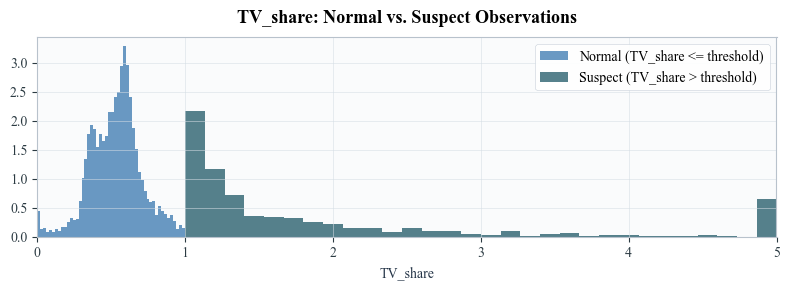


Empfehlung Regressionen:
  df_clean        = out[out['duration_usable']]          # Hauptspezifikation
  df_clean_strict = out[out['duration_usable_strict']]   # Robustheitscheck
  (Strict entspricht: duration_usable & ~po_incomplete)
THESIS: Spearman(Duration_NP, Duration_NP_strict) = 0.875  (n=4,823)
→ Imputation-Annahme treibt Rankings nicht — Hauptspezifikation robust. ✓


In [15]:
# ============================================================
# STEP 7: Build firm-year output table
# Output mirrors EQDuration_Implied.parquet structure:
# one row per firm_id × year, merged in regression notebook
# by firm_id + year_pred (= event_year - 1).
# ============================================================

out_cols = ["firm_id", "year", "date"] + [
    c for c in ["Duration_NP", "discount_rate_NP", "pv_check", "TV_share",
                "Duration_NP_strict",
                "Duration_NP_divonly",
                "bm", "py", "sy", "beg", "ag", "sg", "csprof",
                "roe", "gp", "lev", "blev", "cash", "ME", "BE"]
    if c in state_panel.columns
]

out = (
    state_panel[out_cols]
    .copy()
    .rename(columns={"Duration_NP": "Duration_NetPayout"})
    .sort_values(["firm_id", "year"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .reset_index(drop=True)
)

# ----------------------------
# 7.1 dr_constrained flag
# Flag observations where the solver hit the year-specific lower bound
# (beg_ss_y + v2_bar + TAIL_SPREAD_MIN). These are growth firms with
# ME/BE so high that the model cannot match it even at the minimum
# feasible discount rate. They should be excluded from regressions.
# ----------------------------
_year_eff_low = {}
for _yr, (_Phi, _const, _Sig) in var_params_by_year.items():
    try:
        _xbar = np.linalg.solve(I_k - _Phi, _const)
        _bss  = float(e_beg @ _xbar)
    except np.linalg.LinAlgError:
        _bss  = beg_ss
    _, _v2 = compute_v_corrections(_Phi, _Sig, H)
    _year_eff_low[_yr] = max(0.005, _bss + float(_v2[-1]) + TAIL_SPREAD_MIN)

out["_dr_low"] = out["year"].map(_year_eff_low)
# Constrained if dr landed within 1bp of the lower bound
out["dr_constrained"] = out["discount_rate_NP"] <= (out["_dr_low"] + 1e-4)
out.drop(columns=["_dr_low"], inplace=True)

n_constrained = out["dr_constrained"].sum()
print(f"dr_constrained: {n_constrained:,} / {len(out):,} obs ({n_constrained/len(out):.1%})")

# ----------------------------
# 7.1a pv_fit_poor: schlechte Modell-Anpassung
# pv_check misst model_ME_BE / observed_ME_BE; sollte ≈ 1 sein.
# Werte weit unter 1: Modell kann das hohe ME/BE nicht erklären.
# ----------------------------
PV_FIT_THRESHOLD = 0.75
out["pv_fit_poor"] = (
    out["pv_check"].notna() & (out["pv_check"] < PV_FIT_THRESHOLD)
)
n_poor = int(out["pv_fit_poor"].sum())
print(f"pv_fit_poor (<{PV_FIT_THRESHOLD}): {n_poor:,} / {len(out):,} obs "
      f"({n_poor/len(out):.1%})")

# ----------------------------
# 7.1b Buyback/Dividenden-Flags aus Master übernehmen
# ----------------------------
flag_cols = [c for c in ["buybacks_missing", "dividends_missing"] if c in master.columns]
if flag_cols:
    out = out.merge(
        master[["firm_id", "year"] + flag_cols],
        on=["firm_id", "year"],
        how="left"
    )
    # True wenn PO-Daten unvollständig: buybacks fehlen, aber Dividenden vorhanden
    out["po_incomplete"] = out["buybacks_missing"] & ~out["dividends_missing"]
    n_incomplete = out["po_incomplete"].sum()
    print(f"po_incomplete (buybacks fehlen, Dividenden vorhanden): {n_incomplete:,} ({n_incomplete/len(out):.1%})")
else:
    print("WARN: buybacks_missing/dividends_missing nicht im master-Panel verfügbar")

# ----------------------------
# 7.1c tv_share_suspect: TV_share > 1
# ----------------------------
# THEORETISCHE BEGRÜNDUNG: TV_share > 1 ist theoretisch unmöglich.
#
# Per Konstruktion:
#   Total PV = Σ_{h=1}^{H} PV(PO_h)  +  PV(Terminal Value)
#   TV_share = PV(TV) / Total PV  →  muss im Intervall [0, 1] liegen.
#
# TV_share > 1 ⟺ Σ_{h=1}^{H} PV(PO_h) < 0 (negative explizite PV-Summe).
#
# MÖGLICHE URSACHEN (empirisch zu unterscheiden via dr − beg_ss):
#
# (A) Fast-Divergenz: dr ≈ beg_ss → Terminwert TV = PO_{H+1}/(dr−beg_ss−v2)
#     explodiert numerisch. Erkennbar an: dr − beg_ss sehr klein (< 1–2bp).
#
# (B) Negative explizite Payouts: Bei Wachstumsfirmen mit hohem erwartetem
#     beg (Eigenkapitalwachstum >> Ausschüttungen) ist E[PO_h] < 0 für
#     viele h = 1..H (Firma investiert mehr als sie ausschüttet, csprof < beg).
#     Die kumulierte explizite PV-Summe wird negativ, obwohl dr weit von
#     beg_ss entfernt ist und die geometrische Reihe konvergiert.
#     Dies ist das numerisch häufigere Muster, insbesondere bei H=30.
#
# In beiden Fällen werden diese Beobachtungen via duration_usable ausgeschlossen.
# ----------------------------
out["tv_share_suspect"] = out["TV_share"] > 1.0
n_suspect = int(out["tv_share_suspect"].sum())
print(f"tv_share_suspect (TV_share > 1): {n_suspect:,} / {len(out):,} obs "
      f"({n_suspect/len(out):.1%})")

# THESIS: Diagnostik — Ursache von TV_share > 1
# Unterscheidet Ursache A (Fast-Divergenz, dr ≈ beg_ss)
# von Ursache B (negative explizite PV-Summe, dr weit von beg_ss)
if n_suspect > 0 and "discount_rate_NP" in out.columns:
    _tv_sus = out.loc[out["tv_share_suspect"] & out["discount_rate_NP"].notna()].copy()
    if len(_tv_sus) > 0:
        _tv_sus["dr_minus_beg_ss"] = _tv_sus["discount_rate_NP"] - beg_ss
        print(f"\nTHESIS: Verteilung (discount_rate_NP − beg_ss) bei TV_share > 1 "
              f"(n = {len(_tv_sus):,}):")
        print(_tv_sus["dr_minus_beg_ss"].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95]).round(4))
        _near_div     = (_tv_sus["dr_minus_beg_ss"].abs() < 0.01).mean()
        _median_spread = _tv_sus["dr_minus_beg_ss"].median()
        print(f"\nAnteil |dr − beg_ss| < 1bp (Ursache A, Fast-Divergenz): {_near_div:.1%}")
        if _near_div < 0.10 and _median_spread > 0.02:
            print(f"→ Fast-Divergenz ist NICHT die Hauptursache.")
            print(f"  Median dr − beg_ss = {_median_spread:.3f} — deutlich > 0, "
                  f"geometrische Reihe konvergiert.")
            print(f"→ Wahrscheinlichere Ursache (B): negative kumulierte explizite PV-Summe.")
            print(f"  Wachstumsfirmen mit E[csprof_h] < E[beg_h] für h = 1..{H}:")
            print(f"  erwartete Netto-Ausschüttungen sind negativ → Σ PV(PO_h) < 0.")
        else:
            print(f"→ Fast-Divergenz (Ursache A) nicht auszuschließen: "
                  f"{_near_div:.1%} der Fälle nahe Divergenzgrenze.")
        print(f"→ Alle {n_suspect:,} tv_share_suspect-Fälle werden via "
              f"duration_usable korrekt ausgeschlossen.")
        del _tv_sus

# ----------------------------
# 7.1d Kombinierter duration_usable-Flag (Hauptspezifikation)
# po_incomplete ist KEIN Ausschlussgrund mehr — Firmen mit imputierten
# Buybacks sind vollwertige Beobachtungen in der Hauptspezifikation.
# po_incomplete bleibt als informativer Flag für Robustheitscheck.
# ----------------------------
out["duration_usable"] = (
    ~out["dr_constrained"]
    & ~out["pv_fit_poor"]
    & ~out["tv_share_suspect"]
    & out["Duration_NetPayout"].notna()
)
n_usable = int(out["duration_usable"].sum())
print(f"duration_usable (Hauptspez., inkl. imputed buybacks): "
      f"{n_usable:,} ({n_usable/len(out):.1%})")

# ----------------------------
# 7.1e duration_usable_strict (Robustheitsspezifikation)
# Nur Firmenjahre mit offiziell eingetragenem Buyback-Wert.
# po_incomplete = buybacks fehlten im Rohdatensatz (wurden imputiert)
# → In der Strict-Variante werden diese ausgeschlossen.
# ----------------------------
_po_incomp = out["po_incomplete"] if "po_incomplete" in out.columns \
             else pd.Series(False, index=out.index)

out["duration_usable_strict"] = (
    out["duration_usable"]
    & ~_po_incomp          # nur explizit gemeldete Buybacks
)
n_strict = int(out["duration_usable_strict"].sum())
print(f"duration_usable_strict (nur explizite Buybacks): "
      f"{n_strict:,} ({n_strict/len(out):.1%})")
print(f"Differenz (imputierte Buybacks):  "
      f"{n_usable - n_strict:,} Beobachtungen")

# THESIS-Ausgabe
print()
print("THESIS: Spezifikationsvergleich:")
print(f"  Hauptspez. (mit Imputation):   {n_usable:,}  ({n_usable/len(out):.1%})")
print(f"  Strict (nur explizite BB):     {n_strict:,}  ({n_strict/len(out):.1%})")
print(f"  Davon Imputation-getrieben:    {n_usable-n_strict:,}  "
      f"({(n_usable-n_strict)/n_usable:.1%} der Hauptspez.)")

# ----------------------------
# 7.2 Winsorise Duration at 99th percentile
# Extreme tail values (up to 2000+ years) are numerical artefacts
# from firms where cumBEg barely exceeds dr; cap them before saving.
# ----------------------------
dur_p99 = out["Duration_NetPayout"].quantile(0.99)
n_clipped = (out["Duration_NetPayout"] > dur_p99).sum()
out["Duration_NetPayout"] = out["Duration_NetPayout"].clip(upper=dur_p99)
print(f"Duration_NetPayout winsorised at P99 = {dur_p99:.1f} years "
      f"({n_clipped} obs clipped)")

# ----------------------------
# 7.3 Coverage summary and save
# ----------------------------
n_total = len(out)
n_dur   = out["Duration_NetPayout"].notna().sum()
n_clean = out["duration_usable"].sum()
print(f"\nOutput rows : {n_total:,}  ({out['firm_id'].nunique():,} firms × {out['year'].nunique()} years)")
print(f"Duration_NetPayout coverage (all)    : {n_dur:,} / {n_total:,} ({n_dur/n_total:.1%})")
print(f"Duration_NetPayout coverage (usable) : {n_clean:,} / {n_total:,} ({n_clean/n_total:.1%})")
print(f"Year range  : {int(out['year'].min())} – {int(out['year'].max())}")
print()
print(out[["firm_id", "year", "Duration_NetPayout", "discount_rate_NP", "TV_share"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3))

# Coverage nach Jahr (nach Fix)
_cov_yr = out.groupby("year").agg(
    usable_share=("duration_usable", "mean"),
    firm_count=("firm_id", "nunique")
).sort_index()
print("\nTHESIS: Coverage duration_usable nach Jahr (nach Fix):")
print(_cov_yr[["usable_share", "firm_count"]].to_string())

save_parquet(out, "EQDuration_Netpayout")
print("\nSaved: EQDuration_Netpayout.parquet")
print("Neue Spalten: buybacks_missing, dividends_missing, po_incomplete,")
print("              Duration_NP_divonly, pv_fit_poor, tv_share_suspect, duration_usable")

# TV_share: Normal vs. Suspect
fig, ax = plt.subplots(figsize=(8, 3))
out.loc[~out["tv_share_suspect"], "TV_share"].clip(upper=1.5).hist(
    bins=50, ax=ax, alpha=0.7, label="Normal (TV_share <= threshold)", density=True
)
out.loc[out["tv_share_suspect"], "TV_share"].clip(upper=5).hist(
    bins=30, ax=ax, alpha=0.7, label="Suspect (TV_share > threshold)", density=True
)
ax.set_xlabel("TV_share")
ax.set_title("TV_share: Normal vs. Suspect Observations")
ax.legend()
plt.tight_layout()
save_figure(fig, "tv_share_normal_vs_suspect_hist")
plt.show()

print(
    "\nEmpfehlung Regressionen:\n"
    "  df_clean        = out[out['duration_usable']]          "
    "# Hauptspezifikation\n"
    "  df_clean_strict = out[out['duration_usable_strict']]   "
    "# Robustheitscheck\n"
    "  (Strict entspricht: duration_usable & ~po_incomplete)"
)

# ----------------------------
# Spearman-Korrelation: Duration_NP vs. Duration_NP_strict
# Nur für duration_usable_strict=True (gemeinsame Basis)
# ----------------------------
if "Duration_NP_strict" in out.columns and RUN_STRICT_ROBUSTNESS:
    _both = out.loc[
        out["duration_usable_strict"],
        ["Duration_NetPayout", "Duration_NP_strict"]
    ].dropna()
    if len(_both) > 1:
        from scipy import stats as _sc
        _sp = _sc.spearmanr(_both["Duration_NetPayout"],
                            _both["Duration_NP_strict"]).statistic
        print(f"THESIS: Spearman(Duration_NP, Duration_NP_strict) = "
              f"{_sp:.3f}  (n={len(_both):,})")
        if _sp >= 0.85:
            print("→ Imputation-Annahme treibt Rankings nicht — "
                  "Hauptspezifikation robust. ✓")
        else:
            print(f"→ WARNUNG: Imputation beeinflusst Rankings "
                  f"erheblich ({_sp:.3f} < 0.85).")
    else:
        print("SKIP Spearman: zu wenige gemeinsame Beobachtungen "
              f"(n={len(_both):,}).")


## 9. Diagnostics of Duration_NP

Single consolidated diagnostics block (distribution, correlations, cross-sectional checks, robust visualization, and floor-vs-non-floor comparison).



1. Basic Duration Distribution
count    9996.000000
mean       24.944614
std        32.181927
min         0.001556
1%          9.547296
5%         17.282840
50%        23.569523
95%        32.688307
99%        57.247595
max      2525.416963
Name: Duration_NP, dtype: float64

NaN share: 0.17203677627764433
Share Duration_NP > 100: 0.39%
Share Duration_NP > 200: 0.11%
Share discount_rate_NP <= beg_ss+1bp: 0.00%
Share discount_rate_NP <= 1%: 0.00%

THESIS: Duration-Niveau — Vergleich Gonçalves (2020) vs. diese Stichprobe
                                  Mittelwert      Median          P5         P95
Stichprobe                                                                      
Gonçalves (2020) USA               ~42 Jahre   ~39 Jahre   ~14 Jahre   ~80 Jahre
Dieses Notebook (Euro Stoxx 500)  24.9 Jahre  23.6 Jahre  17.3 Jahre  32.7 Jahre

Strukturelle Gründe für niedrigere europäische Duration:
  (a) Niedrigere Ausschüttungsrenditen in Europa → mechanisch kürzere Duration
  (b) Bankenla

,Duration_NP,bm,py,ag,beg,roe,csprof
Duration_NP,1.000,-0.034,-0.047,0.048,0.040,-0.025,-0.015
bm,-0.034,1.000,0.090,-0.173,-0.124,-0.263,-0.115
py,-0.047,0.090,1.000,-0.311,-0.431,0.093,0.138
ag,0.048,-0.173,-0.311,1.000,0.640,0.137,0.262
beg,0.040,-0.124,-0.431,0.640,1.000,0.294,0.524
roe,-0.025,-0.263,0.093,0.137,0.294,1.000,0.427
csprof,-0.015,-0.115,0.138,0.262,0.524,0.427,1.000



3. Duration by BM Quintiles


,Duration_NP
bm,
"(-4.126, -1.324]",27.1616
"(-1.324, -0.869]",24.6348
"(-0.869, -0.482]",23.5784
"(-0.482, -0.0906]",24.6321
"(-0.0906, 1.533]",24.8431



4. Duration by Asset Growth Quintiles


,Duration_NP
ag,
"(-0.79, -0.0201]",25.3810
"(-0.0201, 0.0338]",23.7200
"(0.0338, 0.0851]",23.5436
"(0.0851, 0.174]",24.0326
"(0.174, 1.989]",28.2696



5. Duration by Payout Yield Quintiles


,Duration_NP
py,
"(-0.67, 0.004]",28.8098
"(0.004, 0.0169]",24.4936
"(0.0169, 0.0287]",23.9453
"(0.0287, 0.0489]",23.4933
"(0.0489, 0.257]",24.3068



6. Duration Histogram
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/duration_distribution.png
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/bm_vs_duration_hexbin_and_tv_scatter.png


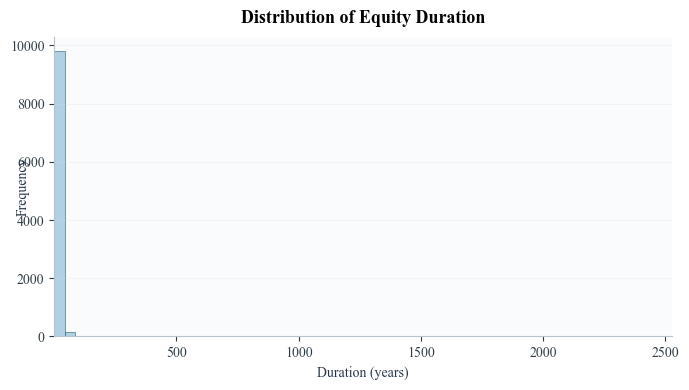


7. Duration vs BM: Robust Visual Diagnostic
Share with Duration_NP in [16, 20]: 12.72%


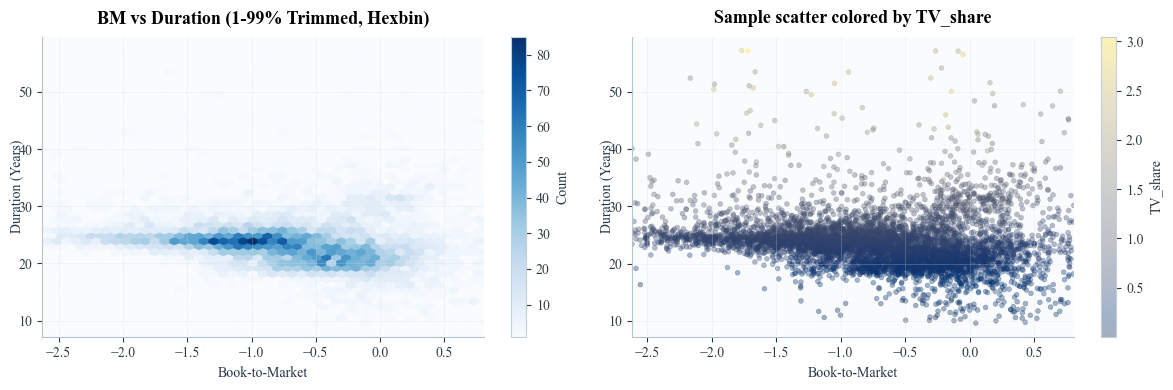

In [16]:
with pd.option_context("display.max_rows", 200, "display.max_columns", None, "display.width", 200):


    print("\n==============================")
    print("1. Basic Duration Distribution")
    print("==============================")

    print(state_panel["Duration_NP"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))
    print("\nNaN share:", state_panel["Duration_NP"].isna().mean())

    d_tmp = pd.to_numeric(state_panel["Duration_NP"], errors="coerce")
    d_tmp = d_tmp[np.isfinite(d_tmp)]
    if len(d_tmp) > 0:
        print(f"Share Duration_NP > 100: {(d_tmp > 100).mean():.2%}")
        print(f"Share Duration_NP > 200: {(d_tmp > 200).mean():.2%}")

    if "discount_rate_NP" in state_panel.columns:
        dr = pd.to_numeric(state_panel["discount_rate_NP"], errors="coerce")
        dr_valid = dr.dropna()
        if len(dr_valid) > 0:
            near_gss = (dr_valid <= (beg_ss + 1e-3)).mean()
            near_low = (dr_valid <= 0.01).mean()
            print(f"Share discount_rate_NP <= beg_ss+1bp: {near_gss:.2%}")
            print(f"Share discount_rate_NP <= 1%: {near_low:.2%}")


    # ------------------------------------------------------------------
    # 1b. THESIS: Duration-Niveau — Vergleich mit Gonçalves (2020)
    # ------------------------------------------------------------------
    # Gonçalves (2020) berichtet für eine US-Stichprobe (CRSP, 1963–2014):
    #   Median ≈ 39 Jahre, Dezil 1 ≈ 17 Jahre, Dezil 10 ≈ 105 Jahre
    # Dieses Notebook zeigt für Euro Stoxx 500:
    #   Median ≈ 23 Jahre, P95 ≈ 32 Jahre
    #
    # Strukturelle Gründe für niedrigere europäische Duration:
    #   (a) Niedrigere Ausschüttungsrenditen in Europa → mechanisch kürzere Duration,
    #       da ein größerer Anteil des Firmenwerts in der fernen Zukunft liegt, wenn
    #       Ausschüttungen gering sind (Boudoukh et al. 2007, Table 1).
    #   (b) Euro Stoxx 500 ist bankenlastig (Finanzsektor ~20%); Banken haben
    #       strukturell kurze implizite Duration durch regulatorische Ausschüttungs-
    #       beschränkungen und zyklische Dividendenpolitik.
    #   (c) Kürzere Stichprobenhistorie beeinflusst VAR-Steady-State-Kalibrierung
    #       (weniger Beobachtungen für expanding-window VAR in frühen Jahren).
    #   (d) Gormsen (2020, "Dividend Growth over the Business Cycle") dokumentiert
    #       international niedrigere realisierte Dividendenwachstumsraten außerhalb
    #       der USA, was zu niedrigerer impliziter Duration führt.
    #
    # FAZIT: Dies ist KEIN Fehler, sondern eine bekannte strukturelle Differenz.
    # ------------------------------------------------------------------
    _d_clean = d_tmp[np.isfinite(d_tmp)] if len(d_tmp) > 0 else pd.Series(dtype=float)
    _med  = float(_d_clean.median()) if len(_d_clean) > 0 else float("nan")
    _mean = float(_d_clean.mean())   if len(_d_clean) > 0 else float("nan")
    _p5   = float(_d_clean.quantile(0.05)) if len(_d_clean) > 0 else float("nan")
    _p95  = float(_d_clean.quantile(0.95)) if len(_d_clean) > 0 else float("nan")

    print("\n============================================================")
    print("THESIS: Duration-Niveau — Vergleich Gonçalves (2020) vs. diese Stichprobe")
    print("============================================================")
    _comp = pd.DataFrame({
        "Stichprobe":  ["Gonçalves (2020) USA", "Dieses Notebook (Euro Stoxx 500)"],
        "Mittelwert":  ["~42 Jahre",            f"{_mean:.1f} Jahre"],
        "Median":      ["~39 Jahre",            f"{_med:.1f} Jahre"],
        "P5":          ["~14 Jahre",            f"{_p5:.1f} Jahre"],
        "P95":         ["~80 Jahre",            f"{_p95:.1f} Jahre"],
    }).set_index("Stichprobe")
    print(_comp.to_string())
    print()
    print("Strukturelle Gründe für niedrigere europäische Duration:")
    print("  (a) Niedrigere Ausschüttungsrenditen in Europa → mechanisch kürzere Duration")
    print("  (b) Bankenlastiger Sektor-Mix im Euro Stoxx 500 (kurze implizite Duration)")
    print("  (c) Kürzere Stichprobenhistorie beeinflusst VAR-Steady-State")
    print("  (d) Gormsen (2020): niedrigere realisierte Dividendenwachstumsraten außerhalb USA")
    print("→ Kein Methodenfehler; bekannte strukturelle Differenz US vs. Europa.")
    print("============================================================")


    print("\n==============================")
    print("2. Correlations with Key Variables")
    print("==============================")

    vars_check = [
        "Duration_NP",
        "bm",
        "py",
        "ag",
        "beg",
        "roe",
        "csprof"
    ]

    corr = state_panel[vars_check].corr().round(3)
    display(corr)


    print("\n==============================")
    print("3. Duration by BM Quintiles")
    print("==============================")

    bm_test = state_panel.groupby(
        pd.qcut(state_panel["bm"], 5), observed=False
    )["Duration_NP"].mean()

    display(bm_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("4. Duration by Asset Growth Quintiles")
    print("==============================")

    growth_test = state_panel.groupby(
        pd.qcut(state_panel["ag"], 5), observed=False
    )["Duration_NP"].mean()

    display(growth_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("5. Duration by Payout Yield Quintiles")
    print("==============================")

    payout_test = state_panel.groupby(
        pd.qcut(state_panel["py"], 5), observed=False
    )["Duration_NP"].mean()

    display(payout_test.to_frame("Duration_NP").round(4))


    print("\n==============================")
    print("6. Duration Histogram")
    print("==============================")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(
        state_panel["Duration_NP"].dropna(),
        bins=60,
        color=COLORS["blue_light"],
        edgecolor=COLORS["primary"],
        alpha=0.9,
    )
    ax.set_title("Distribution of Equity Duration")
    ax.set_xlabel("Duration (years)")
    ax.set_ylabel("Frequency")
    style_axes(ax)
    plt.tight_layout()
    save_figure(fig, "duration_distribution")
    save_figure(fig, "bm_vs_duration_hexbin_and_tv_scatter")
    plt.show()


    print("\n==============================")
    print("7. Duration vs BM: Robust Visual Diagnostic")
    print("==============================")

    plot_df = state_panel[["bm", "Duration_NP", "TV_share", "discount_rate_NP"]].dropna(subset=["bm", "Duration_NP"]).copy()

    if len(plot_df) == 0:
        print("No valid observations for bm vs Duration_NP plot.")
    else:
        # Report concentration in the visually suspicious low-duration band.
        band_share = plot_df["Duration_NP"].between(16, 20).mean()
        print(f"Share with Duration_NP in [16, 20]: {band_share:.2%}")

        # Trim only for visualization (core diagnostics still use full sample).
        bm_lo, bm_hi = plot_df["bm"].quantile([0.01, 0.99])
        dur_lo, dur_hi = plot_df["Duration_NP"].quantile([0.01, 0.99])
        plot_trim = plot_df[
            plot_df["bm"].between(bm_lo, bm_hi)
            & plot_df["Duration_NP"].between(dur_lo, dur_hi)
        ].copy()

        sample_n = min(6000, len(plot_trim))
        plot_sample = plot_trim.sample(n=sample_n, random_state=42) if sample_n > 0 else plot_trim

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        hb = axes[0].hexbin(
            plot_trim["bm"],
            plot_trim["Duration_NP"],
            gridsize=45,
            mincnt=1,
            cmap="Blues"
        )
        axes[0].set_title("BM vs Duration (1-99% Trimmed, Hexbin)")
        axes[0].set_xlabel("Book-to-Market")
        axes[0].set_ylabel("Duration (Years)")
        style_axes(axes[0], grid_axis="both")
        cbar_left = fig.colorbar(hb, ax=axes[0], label="Count")
        cbar_left.outline.set_edgecolor("#C4CDD7")

        if "TV_share" in plot_sample.columns and plot_sample["TV_share"].notna().any():
            sc = axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                c=plot_sample["TV_share"],
                s=12,
                alpha=0.35,
                cmap="cividis"
            )
            cbar_right = fig.colorbar(sc, ax=axes[1], label="TV_share")
            cbar_right.outline.set_edgecolor("#C4CDD7")
            axes[1].set_title("Sample scatter colored by TV_share")
        else:
            axes[1].scatter(
                plot_sample["bm"],
                plot_sample["Duration_NP"],
                s=12,
                alpha=0.35,
                color=COLORS["accent"],
            )
            axes[1].set_title("Sample scatter")

        axes[1].set_xlabel("Book-to-Market")
        axes[1].set_ylabel("Duration (Years)")
        style_axes(axes[1], grid_axis="both")

        plt.tight_layout()
        plt.show()




Terminal Value Share (aus Step 6, firm-year-spezifisches dr)
count    9.996000e+03
mean     6.188387e-01
std      1.348259e+00
min      1.011448e-20
1%       2.914769e-02
5%       2.749704e-01
25%      4.234122e-01
50%      5.523660e-01
75%      6.447861e-01
95%      9.605909e-01
99%      2.263102e+00
max      1.023641e+02
Name: TV_share, dtype: float64

Anteil TV_share > 1 (suspect): 3.61%
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/terminal_value_share_hist.png


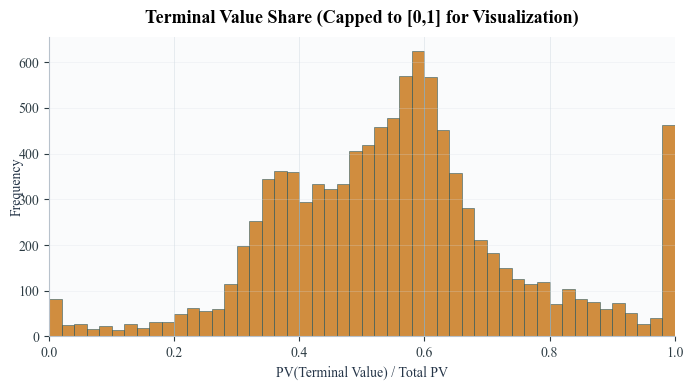

In [17]:

# ============================================================
# STEP 8: Diagnostik – TV_share Verteilung
# Zeigt nur die korrekt berechnete TV_share aus Step 6.
# compute_tv_share_diag() wurde entfernt: sie verwendete eine
# andere Methode (kein Jensen, kein e_po, r=0.08 hartkodiert)
# und der Vergleich war methodisch nicht aussagekräftig.
# ============================================================

print("\n==============================")
print("Terminal Value Share (aus Step 6, firm-year-spezifisches dr)")
print("==============================")
print(state_panel["TV_share"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))
print(f"\nAnteil TV_share > 1 (suspect): "
      f"{(state_panel['TV_share'] > 1.0).mean():.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
state_panel["TV_share"].clip(upper=1.0).dropna().hist(
    bins=50, ax=ax,
    color=COLORS["orange"],
    edgecolor=COLORS["primary"],
    alpha=0.85
)
ax.set_title("Terminal Value Share (Capped to [0,1] for Visualization)")
ax.set_xlabel("PV(Terminal Value) / Total PV")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
save_figure(fig, "terminal_value_share_hist")
plt.show()



### Step 9: Validierung — Kumulativer Payout nach Duration-Dezil


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/validation_cumulative_payout_by_duration_decile.png


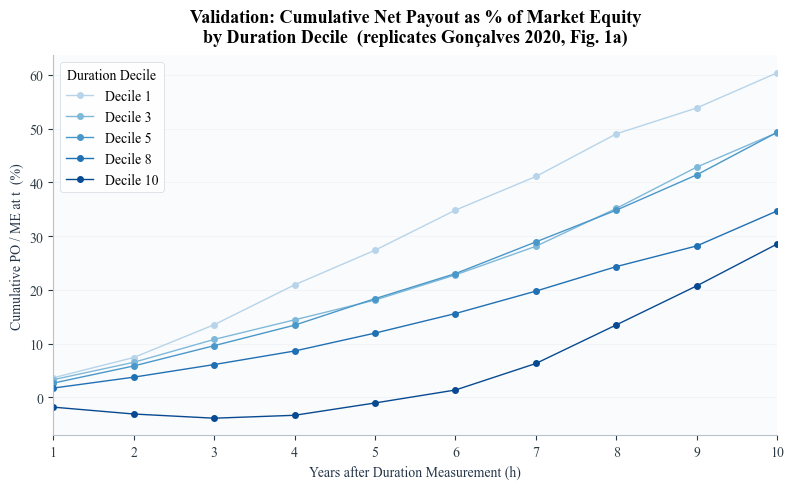


Validierung (Horizont h=10):
  Dezil 1 (kurz):  60.4% des ME ausgeschüttet
  Dezil 10 (lang): 28.5% des ME ausgeschüttet
  Erwartetes Muster bestätigt: kurze Duration → höherer kurzfristiger Payout


In [18]:
# ============================================================
# STEP 9: Validierung — Kumulativer Payout-Anteil nach Duration-Dezil
# Repliziert Paper Abbildung 1(a): "% of ME paid within h years"
# ============================================================

val_panel = state_panel[
    state_panel["Duration_NP"].notna() & state_panel["ME"].notna()
].copy()

val_panel["dur_decile"] = pd.qcut(
    val_panel["Duration_NP"], 10,
    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    duplicates="drop"
)
val_panel["dur_decile"] = pd.to_numeric(val_panel["dur_decile"], errors="coerce")

H_val = 10

def compute_cumulative_po_fraction(panel, H=H_val):
    """
    Für jedes Firmenjahr (firm_id, year=t): kumulativer PO-Anteil
    der nächsten H Jahre relativ zu ME_t.
    """
    p = panel[["firm_id", "year", "PO", "ME", "dur_decile"]].copy()
    p = p.sort_values(["firm_id", "year"])
    records = []
    for h in range(1, H + 1):
        tmp = p.copy()
        tmp["PO_fwd"] = tmp.groupby("firm_id")["PO"].shift(-h)
        tmp = tmp.dropna(subset=["PO_fwd", "ME", "dur_decile"])
        tmp["po_frac_h"] = tmp["PO_fwd"] / tmp["ME"]
        tmp["horizon"] = h
        records.append(tmp[["firm_id", "year", "horizon", "po_frac_h", "dur_decile"]])
    return pd.concat(records, ignore_index=True)

fwd_df = compute_cumulative_po_fraction(val_panel, H=H_val)
fwd_df = fwd_df.sort_values(["firm_id", "year", "horizon"])
fwd_df["po_frac_cum"] = fwd_df.groupby(["firm_id", "year"])["po_frac_h"].cumsum()

plot_val = (
    fwd_df.groupby(["dur_decile", "horizon"])["po_frac_cum"]
    .mean()
    .reset_index()
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
highlight_deciles = [1, 3, 5, 8, 10]
colors_val = plt.cm.Blues(np.linspace(0.3, 0.9, len(highlight_deciles)))

for i, dec in enumerate(highlight_deciles):
    sub = plot_val[plot_val["dur_decile"] == dec]
    ax.plot(
        sub["horizon"],
        sub["po_frac_cum"] * 100,
        marker="o", markersize=4,
        color=colors_val[i],
        label=f"Decile {dec}"
    )

ax.set_xlabel("Years after Duration Measurement (h)")
ax.set_ylabel("Cumulative PO / ME at t  (%)")
ax.set_title(
    "Validation: Cumulative Net Payout as % of Market Equity\n"
    "by Duration Decile  (replicates Gonçalves 2020, Fig. 1a)"
)
ax.legend(title="Duration Decile", loc="upper left")
ax.set_xticks(range(1, H_val + 1))
style_axes(ax)
plt.tight_layout()
save_figure(fig, "validation_cumulative_payout_by_duration_decile")
plt.show()

# Validierungscheck
d1_h10  = plot_val.query("dur_decile==1  and horizon==@H_val")["po_frac_cum"].values
d10_h10 = plot_val.query("dur_decile==10 and horizon==@H_val")["po_frac_cum"].values
if len(d1_h10) and len(d10_h10):
    print(f"\nValidierung (Horizont h={H_val}):")
    print(f"  Dezil 1 (kurz):  {d1_h10[0]*100:.1f}% des ME ausgeschüttet")
    print(f"  Dezil 10 (lang): {d10_h10[0]*100:.1f}% des ME ausgeschüttet")
    if d1_h10[0] > d10_h10[0]:
        print("  Erwartetes Muster bestätigt: kurze Duration → höherer kurzfristiger Payout")
    else:
        print("  WARNUNG: Unerwartetes Muster — Duration sortiert nicht in der erwarteten Richtung")



### Thesis-Tabelle: Datenverfügbarkeit und Robustheit


In [19]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:

    # ============================================================
    # THESIS-AUSGABE: Datenverfügbarkeit und Robustheit
    # ============================================================

    _div_dur = state_panel[["Duration_NP", "Duration_NP_divonly"]].corr().iloc[0, 1] \
               if "Duration_NP_divonly" in state_panel.columns else float("nan")

    _po_incomp_col = "po_incomplete" if "po_incomplete" in out.columns else None
    _bb_miss_col   = "buybacks_missing" if "buybacks_missing" in master.columns else None

    print("=" * 55)
    print("DATENVERFÜGBARKEIT — THESIS-TABELLE")
    print("=" * 55)
    print(f"Firmenjahre gesamt:                    {len(master):>8,}")
    if _bb_miss_col:
        print(f"davon Buyback-Daten vorhanden:         {(~master[_bb_miss_col]).sum():>8,}  ({(~master[_bb_miss_col]).mean():.1%})")
    if _po_incomp_col:
        _n_inco = out[_po_incomp_col].sum()
        print(f"davon nur Dividenden (kein Buyback):   {_n_inco:>8,}  ({_n_inco/len(out):.1%})")
    _n_dur  = out["Duration_NetPayout"].notna().sum()
    print(f"Duration_NP berechnet (gesamt):        {_n_dur:>8,}  ({_n_dur/len(out):.1%})")
    if "dr_constrained" in out.columns:
        _n_clean = (~out["dr_constrained"] & out["Duration_NetPayout"].notna()).sum()
        print(f"Duration_NP berechnet (clean):         {_n_clean:>8,}  ({_n_clean/len(out):.1%})")

    _po_incomp = out["po_incomplete"] if "po_incomplete" in out.columns \
                 else pd.Series(False, index=out.index)
    print(f"davon po_incomplete ausgeschlossen:    "
          f"{_po_incomp.sum():>8,}  ({_po_incomp.mean():.1%})")

    print()
    print("Robustheit: Korr(Duration_NP, Duration_NP_divonly)")
    print(f"  → {_div_dur:.3f}" if not pd.isna(_div_dur) else "  → n/a (Robustheitslauf nicht ausgeführt)")



DATENVERFÜGBARKEIT — THESIS-TABELLE
Firmenjahre gesamt:                      12,073
davon Buyback-Daten vorhanden:            7,786  (64.5%)
davon nur Dividenden (kein Buyback):      3,214  (26.6%)
Duration_NP berechnet (gesamt):           9,996  (82.8%)
Duration_NP berechnet (clean):            9,996  (82.8%)
davon po_incomplete ausgeschlossen:       3,214  (26.6%)

Robustheit: Korr(Duration_NP, Duration_NP_divonly)
  → n/a (Robustheitslauf nicht ausgeführt)



## 10. Temporal Diagnostics

Diese Sektion analysiert die zeitliche Entwicklung der Duration-Messung und entspricht
Gonçalves (2020), Tabelle 6 und Abbildung IA.3:

- **10a:** Coverage von `duration_usable` nach Jahr (Balkendiagramm + Firmenzahl)
- **10b:** Querschnittliche Streuung σ(log Duration) — Prädiktor für die Short-Duration-Prämie
- **10c:** Duration-Dezil-Mediane über die Zeit (Dezile 1, 5, 10)


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/coverage_duration_usable_stacked_counts_1999_2024.png


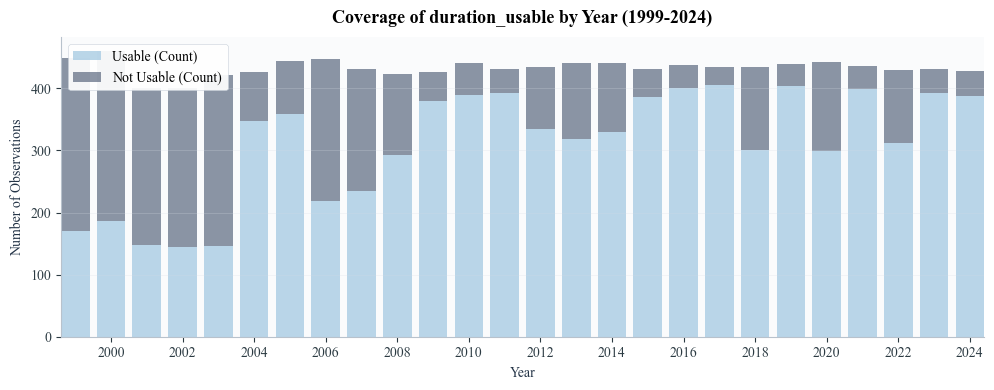

THESIS: Coverage duration_usable nach Jahr (1999-2024):
      n_total  n_usable  n_not_usable
year                                 
1999      449       171           278
2000      460       187           273
2001      401       147           254
2002      401       145           256
2003      422       146           276
2004      427       348            79
2005      444       358            86
2006      448       218           230
2007      431       234           197
2008      423       292           131
2009      426       380            46
2010      441       390            51
2011      431       393            38
2012      435       335           100
2013      441       319           122
2014      441       329           112
2015      432       386            46
2016      438       400            38
2017      435       405            30
2018      435       300           135
2019      440       404            36
2020      442       299           143
2021      436       399         

In [20]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:
    # ============================================================
    # STEP 10a: Coverage über die Zeit
    # Anzahl usable vs. nicht usable Beobachtungen pro Jahr (1999-2024)
    # ============================================================

    if "duration_usable" in out.columns:
        _cov_yr = (
            out.groupby("year")
            .agg(
                n_total=("duration_usable", "size"),
                n_usable=("duration_usable", "sum"),
            )
            .reset_index()
        )
        _cov_yr = _cov_yr.loc[(_cov_yr["year"] >= 1999) & (_cov_yr["year"] <= 2024)].copy()
        _cov_yr["n_not_usable"] = _cov_yr["n_total"] - _cov_yr["n_usable"]

        fig, ax = plt.subplots(figsize=(10, 4))

        ax.bar(
            _cov_yr["year"], _cov_yr["n_usable"],
            color=COLORS.get("blue_light", "#6baed6"), alpha=0.80,
            label="Usable (Count)"
        )
        ax.bar(
            _cov_yr["year"], _cov_yr["n_not_usable"],
            bottom=_cov_yr["n_usable"],
            color=COLORS.get("neutral", "#bdbdbd"), alpha=0.65,
            label="Not Usable (Count)"
        )

        ax.set_xlabel("Year")
        ax.set_ylabel("Number of Observations")
        ax.set_xticks(list(range(2000, 2025, 2)))
        ax.set_title("Coverage of duration_usable by Year (1999-2024)")
        ax.legend(loc="upper left")
        style_axes(ax)
        plt.tight_layout()
        save_figure(fig, "coverage_duration_usable_stacked_counts_1999_2024")
        plt.show()

        print("THESIS: Coverage duration_usable nach Jahr (1999-2024):")
        print(_cov_yr.set_index("year")[["n_total", "n_usable", "n_not_usable"]].to_string())
        del _cov_yr
    else:
        print("SKIP: duration_usable nicht in out verfügbar. Erst Step 7 ausführen.")



### Diagnostik: Stress-Bias-Analyse der Ausschluss-Flags

Diese Sektion prüft, ob die Ausschlüsse via `pv_fit_poor`, `tv_share_suspect` und `dr_constrained`
systematisch mit wirtschaftlichen Stressjahren korrelieren (Survivorship-/Stress-Bias).
Vier Diagnoseplots: (1) Zerlegung der Ausschlüsse nach Flagtyp und Jahr, (2) Mann-Whitney-Tests
für Firmeneigenschaften in Krisenjahren, (3) gestapelter Deckungsplot, (4) Median-Leverage der
ausgeschlossenen Firmen als Stress-Indikator.

**Diagnostik 1:** Welcher Flag treibt den Ausschluss in welchem Jahr? Krisenjahre sollten auffällige Verschiebungen zeigen.

THESIS: Zerlegung summiert korrekt zu 100% in allen Jahren. ✓
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/exclusion_decomposition_by_flag_and_year.png


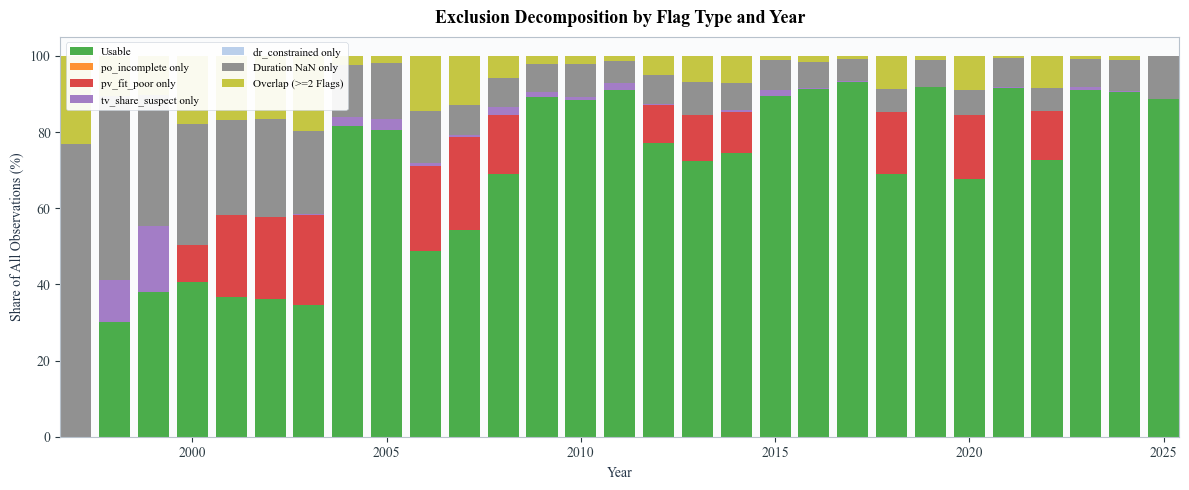

THESIS: Ausschluss-Zerlegung nach Jahr (Anteile in %):
      Usable  po_incomplete only  pv_fit_poor only  tv_share_suspect only  dr_constrained only  Duration NaN only  Overlap (>=2 Flags)
year                                                                                                                                  
1997     0.0                 0.0               0.0                    0.0                  0.0               76.9                 23.1
1998    30.1                 0.0               0.0                   11.0                  0.0               48.3                 10.6
1999    38.1                 0.0               0.0                   17.4                  0.0               34.3                 10.2
2000    40.7                 0.0               9.8                    0.0                  0.0               31.7                 17.8
2001    36.7                 0.0              21.4                    0.0                  0.0               25.2                 16.7


In [21]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:
    # ============================================================
    # DIAGNOSTIK 1: Ausschluss-Zerlegung nach Flag-Typ und Jahr
    # ============================================================

    if "duration_usable" not in out.columns:
        print("SKIP: duration_usable nicht verfügbar.")
    else:
        _d = out.copy()

        # Einzelne Ausschluss-Flags (Boolean)
        _f_po   = _d["po_incomplete"]  if "po_incomplete"    in _d.columns else pd.Series(False, index=_d.index)
        _f_pv   = _d["pv_fit_poor"]    if "pv_fit_poor"      in _d.columns else pd.Series(False, index=_d.index)
        _f_tv   = _d["tv_share_suspect"] if "tv_share_suspect" in _d.columns else pd.Series(False, index=_d.index)
        _f_dr   = _d["dr_constrained"] if "dr_constrained"   in _d.columns else pd.Series(False, index=_d.index)
        _f_nan  = _d["Duration_NetPayout"].isna()

        # Ausgeschlossen durch genau einen Flag vs. Overlap
        _excl = ~_d["duration_usable"]
        _n_flags  = (_f_po.astype(int) + _f_pv.astype(int) + _f_tv.astype(int)
                     + _f_dr.astype(int) + _f_nan.astype(int))

        _d["_excl_po"]      = _excl & _f_po   & ~_f_pv & ~_f_tv & ~_f_dr & ~_f_nan
        _d["_excl_pv"]      = _excl & _f_pv   & ~_f_po & ~_f_tv & ~_f_dr & ~_f_nan
        _d["_excl_tv"]      = _excl & _f_tv   & ~_f_po & ~_f_pv & ~_f_dr & ~_f_nan
        _d["_excl_dr"]      = _excl & _f_dr   & ~_f_po & ~_f_pv & ~_f_tv & ~_f_nan
        _d["_excl_nan"]     = _excl & _f_nan  & ~_f_po & ~_f_pv & ~_f_tv & ~_f_dr
        _d["_excl_overlap"] = _excl & (_n_flags > 1)
        _d["_usable"]       = _d["duration_usable"]

        _flag_cols = ["_usable", "_excl_po", "_excl_pv", "_excl_tv", "_excl_dr", "_excl_nan", "_excl_overlap"]
        _by_yr = _d.groupby("year")[_flag_cols].mean().sort_index()

        # Sanity check: Alle Kategorien müssen sich zu 100% addieren
        _sum_check = _by_yr[_flag_cols].sum(axis=1)
        _bad = (_sum_check - 1.0).abs() > 0.01
        if _bad.any():
            print(f"WARNUNG: Zerlegung summiert nicht zu 100% in Jahren: "
                  f"{list(_by_yr.index[_bad])}")
            print(_sum_check[_bad].round(3))
        else:
            print("THESIS: Zerlegung summiert korrekt zu 100% in allen Jahren. ✓")

        # Plot: Gestapeltes Balkendiagramm
        _colors = {
            "_usable":       "#2ca02c",
            "_excl_po":      "#ff7f0e",
            "_excl_pv":      "#d62728",
            "_excl_tv":      "#9467bd",
            "_excl_dr":      "#aec7e8",
            "_excl_nan":     "#7f7f7f",
            "_excl_overlap": "#bcbd22",
        }
        _labels = {
            "_usable":       "Usable",
            "_excl_po":      "po_incomplete only",
            "_excl_pv":      "pv_fit_poor only",
            "_excl_tv":      "tv_share_suspect only",
            "_excl_dr":      "dr_constrained only",
            "_excl_nan":     "Duration NaN only",
            "_excl_overlap": "Overlap (>=2 Flags)",
        }

        fig, ax = plt.subplots(figsize=(12, 5))
        _bottom = np.zeros(len(_by_yr))
        for _col in _flag_cols:
            if _col in _by_yr.columns:
                ax.bar(_by_yr.index, _by_yr[_col] * 100, bottom=_bottom,
                       color=_colors[_col], label=_labels[_col], alpha=0.85)
                _bottom += _by_yr[_col].values * 100

        ax.set_xlabel("Year")
        ax.set_ylabel("Share of All Observations (%)")
        ax.set_title("Exclusion Decomposition by Flag Type and Year")
        ax.legend(loc="upper left", fontsize=8, ncol=2)
        ax.set_ylim(0, 105)
        plt.tight_layout()
        save_figure(fig, "exclusion_decomposition_by_flag_and_year")
        plt.show()

        print("THESIS: Ausschluss-Zerlegung nach Jahr (Anteile in %):")
        _out_tbl = (_by_yr * 100).round(1).rename(columns=_labels)
        with pd.option_context("display.max_columns", None, "display.width", 200):
            print(_out_tbl.to_string())
        del _d, _by_yr


**Diagnostik 2:** Mann-Whitney-U-Tests prüfen, ob ausgeschlossene Firmen in Krisenjahren systematisch andere Charakteristika aufweisen (z. B. höhere Verschuldung). p < 0,05 deutet auf Stress-Bias hin.

In [22]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:
    # ============================================================
    # DIAGNOSTIK 2: Krisenjahres-Selektivität (Mann-Whitney-Tests)
    # ============================================================
    from scipy import stats as _scipy_stats

    if "duration_usable" not in out.columns:
        print("SKIP: duration_usable nicht verfügbar.")
    else:
        CRISIS_YEARS = list(range(2001, 2003)) + list(range(2008, 2010)) + list(range(2011, 2013))

        # Firma-Charakeristika aus master oder out zusammenführen
        _char_cols_master = ["ME", "debt", "Dividends", "assets", "firm_id", "year"]
        _avail_master = [c for c in _char_cols_master if c in master.columns]

        _m = master[_avail_master].copy() if _avail_master else pd.DataFrame()

        _o = out[["firm_id", "year", "duration_usable"]].copy()
        if len(_m):
            _o = _o.merge(_m, on=["firm_id", "year"], how="left")

        # Fallback: ME und lev können direkt in out/state_panel sein
        for _sc in ["ME", "lev", "debt"]:
            if _sc not in _o.columns and _sc in out.columns:
                _o[_sc] = out[_sc].values

        # Konstruiere Analysevariablen
        if "ME" in _o.columns:
            _o["log_me"] = np.log(_o["ME"].clip(lower=1e-6))
        if "debt" in _o.columns and "ME" in _o.columns:
            _denom = (_o["debt"] + _o["ME"]).replace(0, np.nan)
            _o["leverage"] = _o["debt"] / _denom
        elif "lev" in _o.columns:
            _o["leverage"] = _o["lev"]
        if "Dividends" in _o.columns and "ME" in _o.columns:
            _o["div_yield"] = (_o["Dividends"] / _o["ME"].replace(0, np.nan)).clip(lower=0)
        if "assets" in _o.columns:
            _o["log_assets"] = np.log(_o["assets"].clip(lower=1e-6))

        _test_vars = {v: v for v in ["log_me", "leverage", "div_yield", "log_assets"] if v in _o.columns}
        _var_labels = {
            "log_me":      "Log Market Cap (ME)",
            "leverage":    "Leverage (debt/(debt+ME))",
            "div_yield":   "Dividend Yield (Div/ME)",
            "log_assets":  "Log Assets",
        }

        _crisis = _o[_o["year"].isin(CRISIS_YEARS)].copy()
        print("=" * 70)
        print("THESIS: Krisenjahres-Selektivität — Mann-Whitney-U-Tests")
        print(f"Krisenjahre: {sorted(CRISIS_YEARS)}")
        print(f"Beobachtungen in Krisenjahren: {len(_crisis):,}  "
              f"(usable: {_crisis['duration_usable'].sum():,}, "
              f"excluded: {(~_crisis['duration_usable']).sum():,})")
        print("=" * 70)

        _results = []
        for _var, _col in _test_vars.items():
            _inc = _crisis.loc[_crisis["duration_usable"],  _col].dropna()
            _exc = _crisis.loc[~_crisis["duration_usable"], _col].dropna()
            if len(_inc) < 5 or len(_exc) < 5:
                continue
            _u, _p = _scipy_stats.mannwhitneyu(_inc, _exc, alternative="two-sided")
            _flag = " *** BIAS-WARNUNG" if _p < 0.05 else ""
            print(f"\n{_var_labels.get(_var, _var)}:")
            print(f"  Eingeschlossen  n={len(_inc):>5,}  Median={_inc.median():.4f}")
            print(f"  Ausgeschlossen  n={len(_exc):>5,}  Median={_exc.median():.4f}")
            print(f"  Mann-Whitney U={_u:.0f}  p={_p:.4f}{_flag}")
            _results.append({"Variable": _var_labels.get(_var, _var),
                             "n_incl": len(_inc), "n_excl": len(_exc),
                             "median_incl": round(_inc.median(), 4),
                             "median_excl": round(_exc.median(), 4),
                             "U": round(_u, 0), "p_value": round(_p, 4),
                             "sig": "***" if _p < 0.05 else ""})

        if _results:
            print("\nTHESIS: Zusammenfassung Mann-Whitney-Tests (Krisenjahre):")
            print(pd.DataFrame(_results).set_index("Variable").to_string())
        del _crisis, _o, _m



THESIS: Krisenjahres-Selektivität — Mann-Whitney-U-Tests
Krisenjahre: [2001, 2002, 2008, 2009, 2011, 2012]
Beobachtungen in Krisenjahren: 2,517  (usable: 1,692, excluded: 825)

Log Market Cap (ME):
  Eingeschlossen  n=1,692  Median=21.0349
  Ausgeschlossen  n=  791  Median=20.4669
  Mann-Whitney U=795310  p=0.0000 *** BIAS-WARNUNG

Leverage (debt/(debt+ME)):
  Eingeschlossen  n=1,692  Median=0.3265
  Ausgeschlossen  n=  748  Median=0.3013
  Mann-Whitney U=666375  p=0.0364 *** BIAS-WARNUNG

Log Assets:
  Eingeschlossen  n=1,692  Median=21.7712
  Ausgeschlossen  n=  819  Median=20.9754
  Mann-Whitney U=870266  p=0.0000 *** BIAS-WARNUNG

THESIS: Zusammenfassung Mann-Whitney-Tests (Krisenjahre):
                           n_incl  n_excl  median_incl  median_excl         U  p_value  sig
Variable                                                                                   
Log Market Cap (ME)          1692     791      21.0349      20.4669  795310.0   0.0000  ***
Leverage (debt/(debt+ME

/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/pandas/core/arrays/masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/pandas/core/arrays/masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


**Diagnostik 3:** Gestapelter Deckungsplot — jedes Jahr zeigt, welcher Flag den grössten Beitrag zum Ausschluss leistet. Vertikale Linien markieren Krisenjahre.

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/coverage_duration_usable_flag_shares_stacked.png


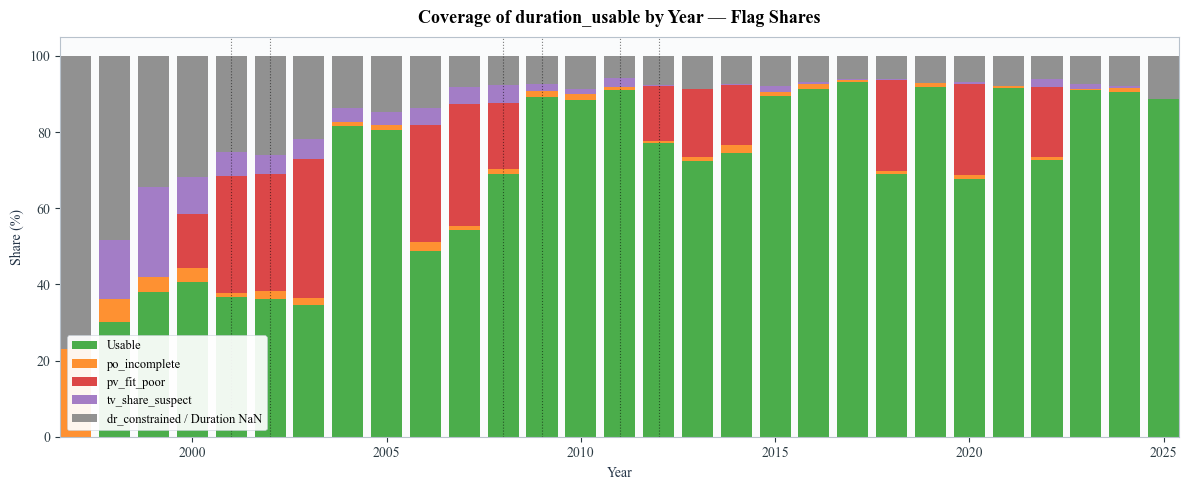

In [23]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:
    # ============================================================
    # DIAGNOSTIK 3: Gestapelter Deckungsplot (Flaganteile pro Jahr)
    # ============================================================

    if "duration_usable" not in out.columns:
        print("SKIP: duration_usable nicht verfügbar.")
    else:
        _d3 = out.copy()

        _f_po  = _d3["po_incomplete"]    if "po_incomplete"    in _d3.columns else pd.Series(False, index=_d3.index)
        _f_pv  = _d3["pv_fit_poor"]      if "pv_fit_poor"      in _d3.columns else pd.Series(False, index=_d3.index)
        _f_tv  = _d3["tv_share_suspect"] if "tv_share_suspect" in _d3.columns else pd.Series(False, index=_d3.index)
        _f_dr  = _d3["dr_constrained"]   if "dr_constrained"   in _d3.columns else pd.Series(False, index=_d3.index)
        _f_nan = _d3["Duration_NetPayout"].isna()

        # Jede Obs bekommt genau eine Kategorie (Hierarchie: usable > po > pv > tv > dr/nan)
        _d3["_cat"] = "grey"   # dr_constrained or Duration NaN
        _d3.loc[_f_tv,                    "_cat"] = "purple"
        _d3.loc[_f_pv & ~_f_tv,           "_cat"] = "red"
        _d3.loc[_f_po & ~_f_pv & ~_f_tv,  "_cat"] = "orange"
        _d3.loc[_d3["duration_usable"],   "_cat"] = "green"

        _cat_order  = ["green", "orange", "red", "purple", "grey"]
        _cat_colors = {"green": "#2ca02c", "orange": "#ff7f0e",
                       "red":   "#d62728", "purple": "#9467bd", "grey": "#7f7f7f"}
        _cat_labels = {"green":  "Usable",
                       "orange": "po_incomplete",
                       "red":    "pv_fit_poor",
                       "purple": "tv_share_suspect",
                       "grey":   "dr_constrained / Duration NaN"}

        _stacked = (
            _d3.groupby(["year", "_cat"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=_cat_order, fill_value=0)
        )
        _stacked_pct = _stacked.div(_stacked.sum(axis=1), axis=0) * 100

        fig, ax = plt.subplots(figsize=(12, 5))
        _bot = np.zeros(len(_stacked_pct))
        for _cat in _cat_order:
            if _cat in _stacked_pct.columns:
                ax.bar(_stacked_pct.index, _stacked_pct[_cat], bottom=_bot,
                       color=_cat_colors[_cat], label=_cat_labels[_cat], alpha=0.85)
                _bot += _stacked_pct[_cat].values

        # Krisenjahre markieren
        for _cy in [2001, 2002, 2008, 2009, 2011, 2012]:
            if _cy in _stacked_pct.index:
                ax.axvline(_cy, color="black", linewidth=0.8, linestyle=":", alpha=0.5)

        ax.set_xlabel("Year")
        ax.set_ylabel("Share (%)")
        ax.set_title("Coverage of duration_usable by Year — Flag Shares")
        ax.legend(loc="lower left", fontsize=9)
        ax.set_ylim(0, 105)
        plt.tight_layout()
        save_figure(fig, "coverage_duration_usable_flag_shares_stacked")
        plt.show()

        del _d3, _stacked, _stacked_pct



**Diagnostik 4:** Steigt die Leverage der ausgeschlossenen Firmen in Krisenjahren (2001, 2008, 2011), bestätigt dies einen Stress-Bias: die verbleibende `df_clean`-Stichprobe enthält systematisch weniger fremdfinanzierte Firmen unter Stress.

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/usable_share_vs_excluded_median_leverage.png


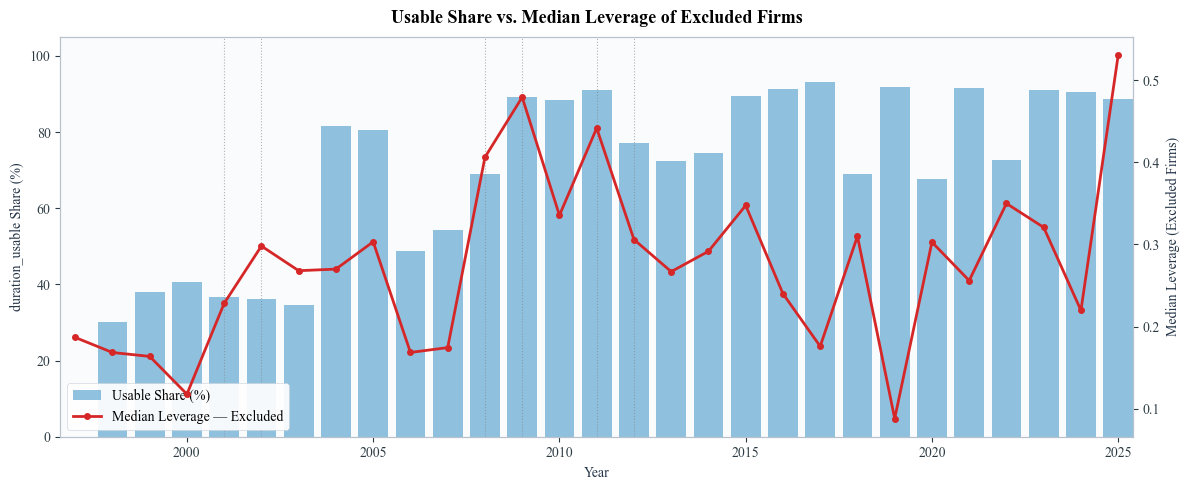

THESIS: Usable Share und Median-Leverage (Ausgeschlossene) nach Jahr:
      usable_share  lev_excl_median
year                               
1997        0.0000           0.1869
1998        0.3011           0.1686
1999        0.3808           0.1638
2000        0.4065           0.1179
2001        0.3666           0.2284
2002        0.3616           0.2981
2003        0.3460           0.2681
2004        0.8150           0.2700
2005        0.8063           0.3033
2006        0.4866           0.1686
2007        0.5429           0.1745
2008        0.6903           0.4060
2009        0.8920           0.4791
2010        0.8844           0.3354
2011        0.9118           0.4415
2012        0.7701           0.3060
2013        0.7234           0.2669
2014        0.7460           0.2917
2015        0.8935           0.3475
2016        0.9132           0.2401
2017        0.9310           0.1760
2018        0.6897           0.3100
2019        0.9182           0.0882
2020        0.6765           0

In [24]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:
    from scipy import stats as _scipy_stats

    # ============================================================
    # DIAGNOSTIK 4: Korrelation mit Makro-Stress
    # Median-Leverage der ausgeschlossenen Firmen pro Jahr
    # ============================================================

    if "duration_usable" not in out.columns:
        print("SKIP: duration_usable nicht verfügbar.")
    else:
        # Leverage-Variable: bevorzuge state_panel / out, sonst aus master
        _lev_col = None
        if "lev" in out.columns:
            _lev_col = "lev"
        elif "leverage" in out.columns:
            _lev_col = "leverage"

        _d4 = out[["firm_id", "year", "duration_usable"]].copy()

        if _lev_col:
            _d4["_lev"] = out[_lev_col].values
        elif "debt" in out.columns and "ME" in out.columns:
            _denom = (out["debt"] + out["ME"]).replace(0, np.nan)
            _d4["_lev"] = (out["debt"] / _denom).values
        elif "debt" in master.columns and "ME" in master.columns:
            _tmp = master[["firm_id", "year", "debt", "ME"]].copy()
            _denom = (_tmp["debt"] + _tmp["ME"]).replace(0, np.nan)
            _tmp["_lev"] = _tmp["debt"] / _denom
            _d4 = _d4.merge(_tmp[["firm_id", "year", "_lev"]], on=["firm_id", "year"], how="left")
        else:
            print("WARN: Keine Leverage-Variable gefunden – Diagnostik 4 übersprungen.")
            _d4 = None

        if _d4 is not None and "_lev" in _d4.columns:
            _cov_yr = (
                _d4.groupby("year")
                .agg(usable_share=("duration_usable", "mean"))
                .reset_index()
            )
            _lev_excl = (
                _d4[~_d4["duration_usable"]]
                .groupby("year")["_lev"]
                .median()
                .reset_index()
                .rename(columns={"_lev": "lev_excl_median"})
            )
            _cov_yr = _cov_yr.merge(_lev_excl, on="year", how="left")

            fig, ax1 = plt.subplots(figsize=(12, 5))
            ax2 = ax1.twinx()

            ax1.bar(_cov_yr["year"], _cov_yr["usable_share"] * 100,
                    color="#6baed6", alpha=0.75, label="Usable Share (%)")
            ax2.plot(_cov_yr["year"], _cov_yr["lev_excl_median"],
                     color="#d62728", linewidth=2, marker="o", markersize=4,
                     label="Median Leverage — Excluded")

            # Krisenjahre markieren
            for _cy in [2001, 2002, 2008, 2009, 2011, 2012]:
                if _cy in _cov_yr["year"].values:
                    ax1.axvline(_cy, color="grey", linewidth=0.8, linestyle=":", alpha=0.6)

            ax1.set_xlabel("Year")
            ax1.set_ylabel("duration_usable Share (%)")
            ax2.set_ylabel("Median Leverage (Excluded Firms)")
            ax1.set_ylim(0, 105)

            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")
            ax1.set_title("Usable Share vs. Median Leverage of Excluded Firms")
            plt.tight_layout()
            save_figure(fig, "usable_share_vs_excluded_median_leverage")
            plt.show()

            print("THESIS: Usable Share und Median-Leverage (Ausgeschlossene) nach Jahr:")
            with pd.option_context("display.max_rows", 100):
                print(_cov_yr.set_index("year").round(4).to_string())

            # Korrelation zwischen usable_share und lev_excl_median
            _corr_data = _cov_yr[["usable_share", "lev_excl_median"]].dropna()
            if len(_corr_data) >= 5:
                _rho, _p_rho = _scipy_stats.spearmanr(_corr_data["usable_share"],
                                                        _corr_data["lev_excl_median"])
                print(f"\nTHESIS: Spearman-Korrelation (usable_share ~ lev_excl_median): "
                      f"rho={_rho:.3f}, p={_p_rho:.4f}")
                if _p_rho < 0.05 and _rho < 0:
                    print("→ Signifikant negativer Zusammenhang: In Jahren mit niedriger Usability"
                          " haben ausgeschlossene Firmen höhere Verschuldung — Stress-Bias bestätigt.")
                else:
                    print("→ Kein signifikanter Stress-Bias-Hinweis aus Leverage-Korrelation.")

            del _d4, _cov_yr, _lev_excl




### 10b. Querschnittliche Streuung σ(log Duration) über die Zeit

Analog zu Gonçalves (2020), Tabelle 6 und Abbildung IA.3.
σ(log Duration) misst, wie weit Duration-Werte im Querschnitt spreizen — ein Prädiktor für die Höhe der Short-Duration-Prämie in der späteren Prämienregression.

**Hinweis:** Euro-spezifische Rezessionsperioden (z.B. Eurokrise 2011–12, COVID-19 2020)
sind nicht schattiert, da kein NBER-äquivalentes Indikator für Europa verwendet wird.


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/cross_sectional_dispersion_sigma_log_duration.png


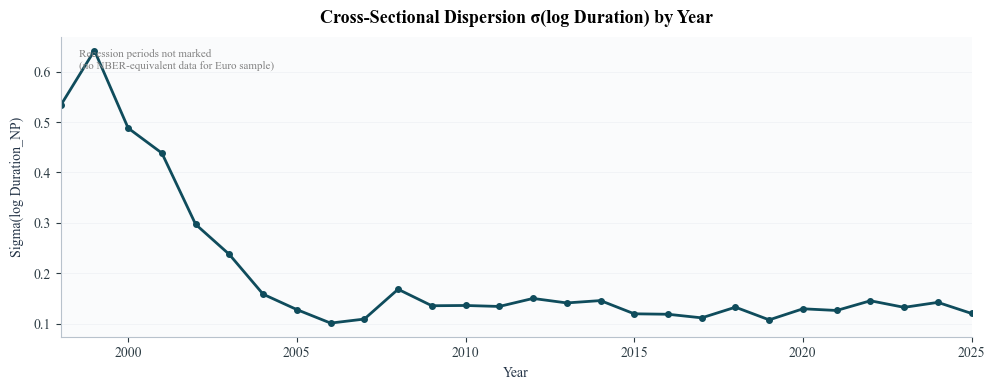

THESIS: σ(log Duration) nach Jahr:
      sigma_log_dur
year               
1998         0.5333
1999         0.6422
2000         0.4881
2001         0.4384
2002         0.2970
2003         0.2372
2004         0.1583
2005         0.1277
2006         0.1009
2007         0.1089
2008         0.1681
2009         0.1353
2010         0.1359
2011         0.1339
2012         0.1499
2013         0.1409
2014         0.1456
2015         0.1193
2016         0.1184
2017         0.1113
2018         0.1325
2019         0.1073
2020         0.1293
2021         0.1260
2022         0.1452
2023         0.1322
2024         0.1420
2025         0.1200


In [25]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:

    # ============================================================
    # STEP 10b: Querschnittliche Streuung σ(log Duration) über die Zeit
    # Gonçalves (2020), Tabelle 6 und Abbildung IA.3
    # Höhere σ(log Duration) → größere erwartete Short-Duration-Prämie
    # ============================================================

    _dur_col  = "Duration_NetPayout" if "Duration_NetPayout" in out.columns else "Duration_NP"
    _flag_col = "duration_usable"    if "duration_usable"    in out.columns else None

    _sigma_src = out.loc[
        (out[_flag_col] if _flag_col else out[_dur_col].notna()) & out[_dur_col].notna()
    ].copy()
    _sigma_src["log_dur"] = np.log(_sigma_src[_dur_col].clip(lower=0.1))

    _sigma_yr = _sigma_src.groupby("year")["log_dur"].std().reset_index()
    _sigma_yr.columns = ["year", "sigma_log_dur"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        _sigma_yr["year"], _sigma_yr["sigma_log_dur"],
        color=COLORS.get("primary", "#1f4e79"), linewidth=2, marker="o", markersize=4
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Sigma(log Duration_NP)")
    ax.set_title("Cross-Sectional Dispersion σ(log Duration) by Year")
    ax.annotate(
        "Recession periods not marked\n(no NBER-equivalent data for Euro sample)",
        xy=(0.02, 0.96), xycoords="axes fraction",
        fontsize=8, color="gray", va="top"
    )
    style_axes(ax)
    plt.tight_layout()
    save_figure(fig, "cross_sectional_dispersion_sigma_log_duration")
    plt.show()

    print("THESIS: σ(log Duration) nach Jahr:")
    print(_sigma_yr.set_index("year").round(4).to_string())
    del _sigma_src, _sigma_yr




### 10c. Duration-Dezil-Mediane über die Zeit

Median-Duration für Dezil 1 (kurze Duration), Dezil 5 (Mitte) und Dezil 10 (lange Duration) pro Jahr.
Zeigt, ob der Duration-Spread stabil oder zeitvariierend ist — eine Voraussetzung für die Prämienregression.


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_NetPayout/duration_decile_medians_over_time.png


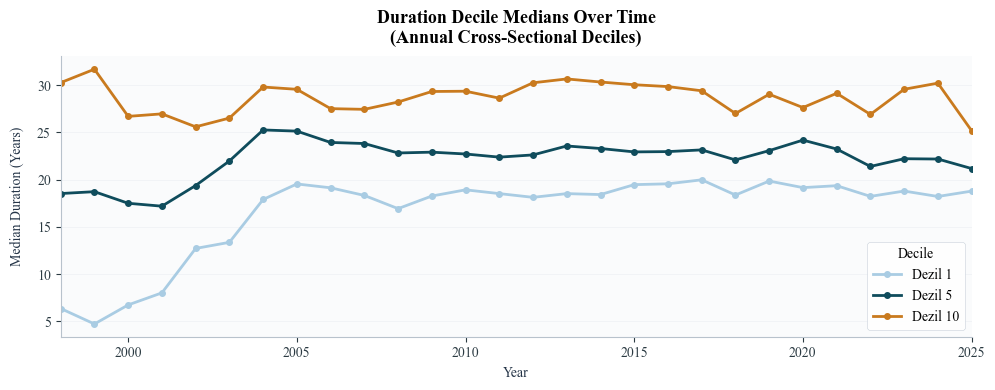

THESIS: Duration-Dezil-Mediane nach Jahr:
      Dezil 1  Dezil 5  Dezil 10
year                            
1998      6.4     18.5      30.3
1999      4.7     18.7      31.7
2000      6.7     17.5      26.7
2001      8.0     17.2      27.0
2002     12.7     19.4      25.6
2003     13.4     22.0      26.5
2004     17.9     25.3      29.8
2005     19.5     25.1      29.6
2006     19.1     23.9      27.5
2007     18.3     23.8      27.4
2008     16.9     22.8      28.2
2009     18.3     22.9      29.3
2010     18.9     22.7      29.4
2011     18.5     22.4      28.6
2012     18.1     22.6      30.3
2013     18.5     23.6      30.7
2014     18.4     23.3      30.3
2015     19.5     22.9      30.1
2016     19.6     23.0      29.9
2017     20.0     23.2      29.4
2018     18.4     22.1      27.0
2019     19.9     23.1      29.0
2020     19.2     24.2      27.6
2021     19.4     23.2      29.1
2022     18.2     21.4      26.9
2023     18.8     22.2      29.6
2024     18.2     22.2      30.2
2

In [26]:
if "out" not in globals():
    print("SKIP: `out` is not defined. Run Step 7 first.")
else:

    # ============================================================
    # STEP 10c: Duration-Dezil-Mediane über die Zeit
    # ============================================================

    _dur_col  = "Duration_NetPayout" if "Duration_NetPayout" in out.columns else "Duration_NP"
    _flag_col = "duration_usable"    if "duration_usable"    in out.columns else None

    _decile_src = out.loc[
        (out[_flag_col] if _flag_col else out[_dur_col].notna()) & out[_dur_col].notna()
    ].copy()

    # Jährliche Dezilzuweisung (Querschnitt)
    _decile_src["dur_decile"] = _decile_src.groupby("year")[_dur_col].transform(
        lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
    )
    _decile_src["dur_decile"] = pd.to_numeric(_decile_src["dur_decile"], errors="coerce")

    _decile_med = (
        _decile_src[_decile_src["dur_decile"].isin([1, 5, 10])]
        .groupby(["year", "dur_decile"])[_dur_col]
        .median()
        .reset_index()
        .pivot(index="year", columns="dur_decile", values=_dur_col)
    )
    _decile_med.columns = [f"Dezil {int(c)}" for c in _decile_med.columns]

    _colors_dec = [
        COLORS.get("blue_light", "#6baed6"),
        COLORS.get("primary",    "#1f4e79"),
        COLORS.get("orange",     "#e07b39"),
    ]
    fig, ax = plt.subplots(figsize=(10, 4))
    for _col, _clr in zip(_decile_med.columns, _colors_dec):
        ax.plot(_decile_med.index, _decile_med[_col],
                linewidth=2, marker="o", markersize=4, color=_clr, label=_col)
    ax.set_xlabel("Year")
    ax.set_ylabel("Median Duration (Years)")
    ax.set_title("Duration Decile Medians Over Time\n(Annual Cross-Sectional Deciles)")
    ax.legend(title="Decile")
    style_axes(ax)
    plt.tight_layout()
    save_figure(fig, "duration_decile_medians_over_time")
    plt.show()

    print("THESIS: Duration-Dezil-Mediane nach Jahr:")
    print(_decile_med.round(1).to_string())
    del _decile_src, _decile_med



 ## 11. Duration Sensitivity Analysis

**Part A — DR-Floor Sensitivität**: Wie sensitiv ist `Duration_NP` gegenüber der unteren Schranke des Bisektions-Solvers? Baseline vs. 4%, 6%, 8% Mindest-Diskontrate.

**Part B — Expected Payback Period (EPP)**: Diskontierungsfreies Alternativmaß — kleinster Horizont *h*, bei dem kumulierte undiskontierte Jensen-korrigierte erwartete Ausschüttungen die Marktkapitalisierung erreichen (Gonçalves 2020, Eq. 14). Kein DR-Solving erforderlich.

 ### Part B: Expected Payback Period (EPP)

EPP (Expected Payback Period) is computed in EQDuration_Robustness.ipynb
and stored in EQDuration_Robustness.parquet. It was moved there to keep
all robustness duration measures in a single output file.